In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pymn
import anndata as ad

In [2]:
import warnings
import logging
import matplotlib as mpl
import matplotlib.pyplot as plt

# Suppress matplotlib font warnings
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")

# Either remove Arial
mpl.rcParams["font.family"] = "sans-serif"


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from typing import Tuple, Optional, Sequence, Literal
import anndata as ad
import pymn

def plot_mn_cross_two(
    adata_x,
    adata_y,
    *,
    study_col: str = "study_id",
    ct_col: str = "cell.type",
    cmap: str = "coolwarm",
    order: Optional[str] = "mean",
    figsize: Tuple[float, float] = (8, 8),
    fast_version: bool = True,
    exclude_cts: Sequence[str] = ("Other",),
    annotate: Literal["row","col","global","none"] = "none",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    use_genes: str = "all",
    genes: Sequence[str] = (),
    layer: Optional[str] = None,
    save: Optional[str] = None,        # NEW
    dpi: int = 600,                    # NEW
    font: str = "Arial",              # NEW
    return_artists: bool = False
):
    # --- sanity
    for A, name in [(adata_x, "adata_x"), (adata_y, "adata_y")]:
        if study_col not in A.obs.columns:
            raise KeyError(f"{name}.obs['{study_col}'] not found")
        if ct_col not in A.obs.columns:
            raise KeyError(f"{name}.obs['{ct_col}'] not found")
        if layer is not None and layer not in A.layers:
            raise KeyError(f"{name}.layers['{layer}'] not found")

    # --- use layer as X if requested
    if layer is not None:
        adata_x_use = adata_x.copy()
        adata_y_use = adata_y.copy()
        adata_x_use.X = adata_x_use.layers[layer].copy()
        adata_y_use.X = adata_y_use.layers[layer].copy()
    else:
        adata_x_use = adata_x
        adata_y_use = adata_y

    # timepoint tokens
    tps_x = pd.Index(adata_x_use.obs[study_col].astype(str).unique())
    tps_y = pd.Index(adata_y_use.obs[study_col].astype(str).unique())
    tp_x = str(sorted(tps_x.astype(str))[0])
    tp_y = str(sorted(tps_y.astype(str))[0])

    tp_all = pd.Index(tps_x.astype(str)).union(pd.Index(tps_y.astype(str)))
    tp_set_lower = set(tp_all.str.casefold())

    # concat for MN
    A = ad.concat([adata_x_use, adata_y_use], join="outer", label=None, merge="unique")
    A.obs[study_col] = A.obs[study_col].astype(str)
    A.obs[ct_col] = A.obs[ct_col].astype(str)
    A.var["all"] = True

    # run MetaNeighborUS
    if use_genes == "all":
        pymn.MetaNeighborUS(
            A, study_col=study_col, ct_col=ct_col,
            var_genes="all", one_vs_best=False, fast_version=fast_version
        )
        pymn.MetaNeighborUS(
            A, study_col=study_col, ct_col=ct_col,
            var_genes="all", one_vs_best=True, fast_version=fast_version
        )

    elif use_genes in ("choose", "custom"):
        shared_set = set(genes)
        A.var["choose"] = A.var_names.isin(shared_set)

        pymn.MetaNeighborUS(
            A, study_col=study_col, ct_col=ct_col,
            var_genes="choose", one_vs_best=False, fast_version=fast_version
        )
        pymn.MetaNeighborUS(
            A, study_col=study_col, ct_col=ct_col,
            var_genes="choose", one_vs_best=True, fast_version=fast_version
        )

    elif use_genes == "variable":
        pymn.variableGenes(A, study_col=study_col)

        pymn.MetaNeighborUS(
            A, study_col=study_col, ct_col=ct_col,
            var_genes="highly_variable", one_vs_best=False, fast_version=fast_version
        )
        pymn.MetaNeighborUS(
            A, study_col=study_col, ct_col=ct_col,
            var_genes="highly_variable", one_vs_best=True, fast_version=fast_version
        )

        hv_genes = A.var.index[A.var["highly_variable"]].to_list()
        #for g in hv_genes:
        #    print(g)

    else:
        raise ValueError("use_genes must be 'all', 'variable', 'choose', or 'custom'")

    scores = A.uns["MetaNeighborUS"]

    # --- robust label parser
    def _split_label_robust(lbl: str):
        toks = [p.strip() for p in re.split(r"[|:/\-]+", str(lbl)) if p.strip()]
        if not toks:
            return str(lbl), ""
        tp_idx = None
        for i, t in enumerate(toks):
            if t.casefold() in tp_set_lower:
                tp_idx = i
                break
        if tp_idx is None:
            return (" | ".join(toks[:-1]) if len(toks) > 1 else toks[0], toks[-1])
        ct_tokens = toks[:tp_idx] + toks[tp_idx+1:]
        ct = " | ".join(ct_tokens) if ct_tokens else toks[tp_idx]
        return ct, toks[tp_idx]

    def _get_ct(lbl: str): 
        return _split_label_robust(lbl)[0]

    def _get_tp(lbl: str): 
        return _split_label_robust(lbl)[1]

    # ensure DataFrame with labels
    if not isinstance(scores, pd.DataFrame):
        combos = (
            A.obs[[ct_col, study_col]]
            .drop_duplicates()
            .sort_values([ct_col, study_col])
            .assign(label=lambda d: d[ct_col] + "|" + d[study_col])
        )
        labels = combos["label"].tolist()
        scores = pd.DataFrame(scores, index=labels, columns=labels)

    # exclude CTs
    exclude_set = {s.casefold() for s in exclude_cts}

    def _keep_label(lbl: str) -> bool:
        return _get_ct(lbl).casefold() not in exclude_set

    # masks for chosen timepoints
    row_tp = scores.index.to_series().map(_get_tp).astype(str)
    col_tp = scores.columns.to_series().map(_get_tp).astype(str)

    row_mask = (
        row_tp.str.casefold().eq(tp_y.casefold()) &
        scores.index.to_series().map(_keep_label)
    )
    col_mask = (
        col_tp.str.casefold().eq(tp_x.casefold()) &
        scores.columns.to_series().map(_keep_label)
    )

    if not row_mask.any():
        raise ValueError(
            f"No rows found for timepoint '{tp_y}' after exclusion {exclude_cts}. "
            f"Seen row timepoints: {row_tp.drop_duplicates().tolist()}"
        )
    if not col_mask.any():
        raise ValueError(
            f"No columns found for timepoint '{tp_x}' after exclusion {exclude_cts}. "
            f"Seen col timepoints: {col_tp.drop_duplicates().tolist()}"
        )

    sub = scores.loc[row_mask, col_mask].copy()

    # ordering
    if order in ("mean", "row", "col", "name", "name_natural"):
        if order in ("mean", "row"):
            sub = sub.loc[sub.mean(axis=1).sort_values(ascending=False).index]
        if order in ("mean", "col"):
            sub = sub.loc[:, sub.mean(axis=0).sort_values(ascending=False).index]
        if order in ("name", "name_natural"):
            if order == "name":
                row_index = (
                    pd.Series([_get_ct(i) for i in sub.index], index=sub.index)
                    .str.lower()
                    .sort_values()
                    .index
                )
                col_index = (
                    pd.Series([_get_ct(j) for j in sub.columns], index=sub.columns)
                    .str.lower()
                    .sort_values()
                    .index
                )
            else:
                def _nat_keys(s):
                    return [
                        int(t) if t.isdigit() else t.lower()
                        for t in re.findall(r"\d+|\D+", s)
                    ]
                row_index = sorted(sub.index, key=lambda i: _nat_keys(_get_ct(i)))
                col_index = sorted(sub.columns, key=lambda j: _nat_keys(_get_ct(j)))

            sub = sub.loc[row_index, col_index]

    elif order is not None:
        raise ValueError("order must be None | 'mean' | 'row' | 'col' | 'name' | 'name_natural'")

    # tick labels
    row_ct = [_get_ct(i) for i in sub.index]
    col_ct = [_get_ct(j) for j in sub.columns]

    # plot
        # plot
    plt.rcParams["font.family"] = font
    plt.rcParams["svg.fonttype"] = "none"
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        sub.values,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax.set_xticks(range(sub.shape[1]))
    ax.set_xticklabels(col_ct, rotation=90, fontsize=8, ha="center", va="top")

    ax.set_yticks(range(sub.shape[0]))
    ax.set_yticklabels(row_ct, fontsize=8)

    ax.set_xlabel(f"Cell types @ {tp_x}", fontsize=10)
    ax.set_ylabel(f"Cell types @ {tp_y}", fontsize=10)

    title_layer = f", layer={layer}" if layer is not None else ""
    ax.set_title(
        f"MetaNeighborUS: {tp_y} rows vs {tp_x} cols{title_layer}",
        fontsize=11,
        pad=8
    )

    # remove heavy frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)

    # optional grid lines between cells
    ax.set_xticks(np.arange(-0.5, sub.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, sub.shape[0], 1), minor=True)
    #ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
    #ax.tick_params(which="minor", bottom=False, left=False)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("AUROC", fontsize=9)
    cbar.ax.tick_params(labelsize=8, length=2)

    plt.tight_layout()

    if save is not None:
        fig.savefig(save, dpi=dpi, bbox_inches="tight", transparent=True)
        print(f"Saved figure to: {save}")

    plt.show()
    return (sub, fig, ax) if return_artists else sub

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Optional, Sequence, Tuple, Union

def fraction_along_line_curves(
    adata,
    cat_col: str,                                # e.g. "excitatory_group"
    p0: Tuple[float, float],
    p1: Tuple[float, float],
    bins: int = 60,
    clip_to_segment: bool = True,
    smooth_window: int = 1,     
    highlight= None,# rolling mean in bins; 1 = no smoothing
    palette_hex: Optional[Dict[str, str]] = None,# {"RL":"#aaddff","Other":"#d3d3d3",...}
    include: Optional[Sequence[str]] = None,     # restrict/order categories
    order_by: Union[str, int] = "mean",          # "mean" | "median" | "center" | int (bin index)
    top_k: Optional[int] = None,                 # plot only top-k most abundant (after ordering)
    normalize: Optional[str] = None,             # None | "by_max" | "by_sum" | "zscore" | "minmax"
    robust_max_pct: Optional[float] = None,      # e.g. 0.99 to ignore outliers for by_max
    lw: float = 2.5,
    alpha: float = 1.0,
    return_df: bool = False,
    _eps: float = 1e-9,                          # numerical safety
    fill_under: bool = True,
    fill_alpha: float = 0.22,
    show: Optional[Sequence[str]] = None,    
    save_prefix = "plot"# NEW: only show selected curves
):
    """
    Plot fractions of categories along a line segment through spatial coordinates.

    Parameters
    ----------
    show : list of str, optional
        If provided, only these categories will be plotted (but all are still used
        for normalization, ordering, and scaling).
    """
    coords = np.asarray(adata.obsm["spatial"])
    cats = adata.obs[cat_col].astype(str).to_numpy()

    # --- line geometry + projections
    p0 = np.asarray(p0, float); p1 = np.asarray(p1, float)
    v = p1 - p0; L = np.linalg.norm(v)
    if L == 0:
        raise ValueError("p0 and p1 must be different points")
    u = v / L
    t = (coords - p0) @ u
    if clip_to_segment:
        t = np.clip(t, 0, L)

    # --- binning
    edges = np.linspace(0, L, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bidx = np.clip(np.digitize(t, edges) - 1, 0, bins - 1)

    # --- counts per (bin x category)
    wide = pd.crosstab(pd.Series(bidx, name="bin"),
                       pd.Series(cats, name="category")).astype(float)
    wide = wide.reindex(range(bins), fill_value=0.0).sort_index()

    if wide.columns.has_duplicates:
        wide = wide.T.groupby(level=0).sum().T

    # restrict/order categories (pre-filter)
    if include is not None:
        include = list(dict.fromkeys(include))
        keep = [c for c in include if c in wide.columns]
        if not keep:
            raise ValueError("No categories from `include` found in the data.")
        wide = wide.reindex(columns=keep)

    # --- fractions per bin (sum across cats = 1 for each bin with cells)
    rs = wide.sum(axis=1)
    frac = wide.copy()
    nz = rs > 0
    frac.loc[nz] = frac.loc[nz].div(rs[nz], axis=0)
    frac.loc[~nz] = 0.0

    # --- optional smoothing (along mediolateral axis)
    k = max(1, int(smooth_window))
    frac_sm = frac.rolling(window=k, center=True, min_periods=1).mean() if k > 1 else frac

    # --- choose draw order using UN-normalized abundance so large groups remain on top
    if isinstance(order_by, int):
        idx = int(np.clip(order_by, 0, bins - 1))
        order = frac_sm.iloc[idx].sort_values(ascending=False).index.tolist()
    elif order_by == "center":
        idx = bins // 2
        order = frac_sm.iloc[idx].sort_values(ascending=False).index.tolist()
    elif order_by == "median":
        order = frac_sm.median(axis=0).sort_values(ascending=False).index.tolist()
    else:  # "mean"
        order = frac_sm.mean(axis=0).sort_values(ascending=False).index.tolist()

    if top_k is not None:
        order = order[:int(top_k)]

    # --- per-category normalization across the mediolateral axis
    Y = frac_sm[order].copy()

    def _normalize(df: pd.DataFrame) -> pd.DataFrame:
        if normalize is None:
            return df
        if normalize == "by_max":
            denom = (df.quantile(robust_max_pct, axis=0) if robust_max_pct is not None else df.max(axis=0))
            denom = denom.replace(0.0, np.nan)
            return df.divide(denom + _eps)
        if normalize == "by_sum":
            denom = df.sum(axis=0).replace(0.0, np.nan)
            return df.divide(denom + _eps)
        if normalize == "zscore":
            mu = df.mean(axis=0)
            sd = df.std(axis=0).replace(0.0, np.nan)
            return (df - mu) / (sd + _eps)
        if normalize == "minmax":
            mn = df.min(axis=0)
            mx = df.max(axis=0)
            den = (mx - mn).replace(0.0, np.nan)
            return (df - mn) / (den + _eps)
        raise ValueError("normalize must be None | 'by_max' | 'by_sum' | 'zscore' | 'minmax'")

    Y_norm = _normalize(Y)

    # --- plot (lines + shaded area under each curve)
    fig, ax = plt.subplots(figsize=(12, 4))

    # --- FILTER: show only selected categories if provided ---
    plot_order = order[::-1]  # least abundant first
    highlight = set(show) if show is not None else None

    for c in plot_order:
        y = np.asarray(Y_norm[c], dtype=float).ravel()

        if highlight is not None:
            if c in highlight:
                color = palette_hex.get(c, "red") if palette_hex else "red"
                this_alpha = 1.0
                this_lw = lw
                this_fill_alpha = fill_alpha
                z = 3
            else:
                color = "lightgrey"
                this_alpha = 0.7
                this_lw = lw * 0.8
                this_fill_alpha = 0.1
                z = 1
        else:
            color = palette_hex.get(c) if palette_hex else None
            this_alpha = alpha
            this_lw = lw
            this_fill_alpha = fill_alpha
            z = 3

        (ln,) = ax.plot(
            centers,
            y,
            label=c,
            lw=this_lw,
            alpha=this_alpha,
            color=color,
            zorder=z
        )

        if fill_under:
            ax.fill_between(
                centers,
                np.zeros_like(y),
                y,
                color=color,
                alpha=this_fill_alpha,
                linewidth=0,
                zorder=z-1
            )

        
    ax.set_xlim(0, L)
    # sensible y-lims based on normalization mode
    if normalize in ("by_max", "minmax"):
        ax.set_ylim(0, 1)
    else:
        y_min = np.nanmin(Y_norm.values)
        y_max = np.nanmax(Y_norm.values)
        pad = 0.05 * (y_max - y_min + _eps)
        ax.set_ylim(y_min - pad, y_max + pad)

        # remove axes/grid/legend/title
    ax.set_axis_off()
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    plt.tight_layout(pad=0)

    fig.savefig(
        f"{save_prefix}.pdf",
        bbox_inches="tight",
        pad_inches=0,
        transparent=True
    )

    fig.savefig(
        f"{save_prefix}.svg",
        bbox_inches="tight",
        pad_inches=0,
        transparent=True
    )

    if return_df:
        # long-form of BOTH raw fraction and the plotted (possibly normalized) values
        long_raw = (Y.rename_axis("bin").reset_index()
                      .melt(id_vars="bin", var_name="category", value_name="fraction"))
        long_raw["t_center"] = centers[long_raw["bin"].to_numpy()]

        long_norm = (Y_norm.rename_axis("bin").reset_index()
                        .melt(id_vars="bin", var_name="category", value_name="value"))
        long_norm["t_center"] = centers[long_norm["bin"].to_numpy()]
        return (long_norm, Y_norm, long_raw, Y)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Optional, Sequence, Tuple, Union


def fraction_along_line_curves(
    adata,
    cat_col: str,
    p0: Tuple[float, float],
    p1: Tuple[float, float],
    bins: int = 60,
    clip_to_segment: bool = True,
    max_perp_distance: Optional[float] = None,
    smooth_window: int = 1,
    highlight=None,
    palette_hex: Optional[Dict[str, str]] = None,
    include: Optional[Sequence[str]] = None,
    order_by: Union[str, int] = "mean",
    top_k: Optional[int] = None,
    normalize: Optional[str] = None,
    robust_max_pct: Optional[float] = None,
    lw: float = 2.5,
    alpha: float = 1.0,
    return_df: bool = False,
    _eps: float = 1e-9,
    fill_under: bool = True,
    fill_alpha: float = 0.22,
    show: Optional[Sequence[str]] = None,
    save_prefix: str = "plot",
):
    """
    Plot category fractions along a spatial line segment.

    Cells can be restricted to:
      1. projections that fall inside the p0→p1 segment
      2. a maximum perpendicular distance from the line

    Parameters
    ----------
    max_perp_distance
        Maximum perpendicular distance from the line.
        If None, cells at any perpendicular distance are retained.
    """

    # --------------------------------------------------
    # Get coordinates and categories
    # --------------------------------------------------
    coords = np.asarray(adata.obsm["spatial"], dtype=float)
    cats = adata.obs[cat_col].astype(str).to_numpy()

    # --------------------------------------------------
    # Line geometry
    # --------------------------------------------------
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)

    v = p1 - p0
    L = np.linalg.norm(v)

    if L == 0:
        raise ValueError("p0 and p1 must be different points")

    u = v / L

    # Vector from p0 to each cell
    relative = coords - p0

    # Position of each cell along the line
    t = relative @ u

    # Perpendicular distance from each cell to the line
    projected = np.outer(t, u)
    perp_distance = np.linalg.norm(relative - projected, axis=1)

    # --------------------------------------------------
    # Filter cells rather than clipping them to endpoints
    # --------------------------------------------------
    valid = np.ones(len(t), dtype=bool)

    if clip_to_segment:
        valid &= (t >= 0) & (t <= L)

    if max_perp_distance is not None:
        valid &= perp_distance <= max_perp_distance

    coords = coords[valid]
    cats = cats[valid]
    t = t[valid]
    perp_distance = perp_distance[valid]

    if len(t) == 0:
        raise ValueError(
            "No cells remain after segment and perpendicular-distance filtering."
        )

    print(
        f"Using {len(t)} of {adata.n_obs} cells "
        f"within the requested line region"
    )

    # --------------------------------------------------
    # Bin positions along the line
    # --------------------------------------------------
    edges = np.linspace(0, L, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    bidx = np.digitize(t, edges) - 1
    bidx = np.clip(bidx, 0, bins - 1)

    # --------------------------------------------------
    # Counts per bin and category
    # --------------------------------------------------
    wide = pd.crosstab(
        pd.Series(bidx, name="bin"),
        pd.Series(cats, name="category"),
    ).astype(float)

    wide = wide.reindex(range(bins), fill_value=0.0).sort_index()

    if wide.columns.has_duplicates:
        wide = wide.T.groupby(level=0).sum().T

    # --------------------------------------------------
    # Restrict and order categories
    # --------------------------------------------------
    if include is not None:
        include = list(dict.fromkeys(include))
        keep = [c for c in include if c in wide.columns]

        if not keep:
            raise ValueError("No categories from `include` found in the data.")

        wide = wide.reindex(columns=keep)

    # --------------------------------------------------
    # Fraction of cells in each category within each bin
    # --------------------------------------------------
    rs = wide.sum(axis=1)

    frac = wide.copy()

    nz = rs > 0
    frac.loc[nz] = frac.loc[nz].div(rs[nz], axis=0)
    frac.loc[~nz] = 0.0

    # --------------------------------------------------
    # Smooth along the line
    # --------------------------------------------------
    k = max(1, int(smooth_window))

    if k > 1:
        frac_sm = frac.rolling(
            window=k,
            center=True,
            min_periods=1,
        ).mean()
    else:
        frac_sm = frac

    # --------------------------------------------------
    # Choose category ordering
    # --------------------------------------------------
    if isinstance(order_by, int):
        idx = int(np.clip(order_by, 0, bins - 1))
        order = (
            frac_sm.iloc[idx]
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    elif order_by == "center":
        idx = bins // 2
        order = (
            frac_sm.iloc[idx]
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    elif order_by == "median":
        order = (
            frac_sm.median(axis=0)
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    else:
        order = (
            frac_sm.mean(axis=0)
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    if top_k is not None:
        order = order[: int(top_k)]

    Y = frac_sm[order].copy()

    # --------------------------------------------------
    # Normalize each category across bins
    # --------------------------------------------------
    def _normalize(df: pd.DataFrame) -> pd.DataFrame:
        if normalize is None:
            return df

        if normalize == "by_max":
            if robust_max_pct is not None:
                denom = df.quantile(robust_max_pct, axis=0)
            else:
                denom = df.max(axis=0)

            denom = denom.replace(0.0, np.nan)
            return df.divide(denom + _eps)

        if normalize == "by_sum":
            denom = df.sum(axis=0).replace(0.0, np.nan)
            return df.divide(denom + _eps)

        if normalize == "zscore":
            mu = df.mean(axis=0)
            sd = df.std(axis=0).replace(0.0, np.nan)
            return (df - mu) / (sd + _eps)

        if normalize == "minmax":
            mn = df.min(axis=0)
            mx = df.max(axis=0)
            den = (mx - mn).replace(0.0, np.nan)
            return (df - mn) / (den + _eps)

        raise ValueError(
            "normalize must be None, 'by_max', 'by_sum', "
            "'zscore', or 'minmax'"
        )

    Y_norm = _normalize(Y)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 4))

    plot_order = order[::-1]
    highlighted = set(show) if show is not None else None

    for c in plot_order:
        y = np.asarray(Y_norm[c], dtype=float).ravel()

        if highlighted is not None:
            if c in highlighted:
                color = (
                    palette_hex.get(c, "red")
                    if palette_hex
                    else "red"
                )
                this_alpha = 1.0
                this_lw = lw
                this_fill_alpha = fill_alpha
                z = 3
            else:
                color = "lightgrey"
                this_alpha = 0.7
                this_lw = lw * 0.8
                this_fill_alpha = 0.1
                z = 1
        else:
            color = palette_hex.get(c) if palette_hex else None
            this_alpha = alpha
            this_lw = lw
            this_fill_alpha = fill_alpha
            z = 3

        ax.plot(
            centers,
            y,
            label=c,
            lw=this_lw,
            alpha=this_alpha,
            color=color,
            zorder=z,
        )

        if fill_under:
            ax.fill_between(
                centers,
                np.zeros_like(y),
                y,
                color=color,
                alpha=this_fill_alpha,
                linewidth=0,
                zorder=z - 1,
            )

    ax.set_xlim(0, L)

    if normalize in ("by_max", "minmax"):
        ax.set_ylim(0, 1)
    else:
        y_min = np.nanmin(Y_norm.values)
        y_max = np.nanmax(Y_norm.values)
        pad = 0.05 * (y_max - y_min + _eps)
        ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_axis_off()
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

    plt.tight_layout(pad=0)

    fig.savefig(
        f"{save_prefix}.pdf",
        bbox_inches="tight",
        pad_inches=0,
        transparent=True,
    )

    fig.savefig(
        f"{save_prefix}.svg",
        bbox_inches="tight",
        pad_inches=0,
        transparent=True,
    )

    if return_df:
        long_raw = (
            Y.rename_axis("bin")
            .reset_index()
            .melt(
                id_vars="bin",
                var_name="category",
                value_name="fraction",
            )
        )

        long_raw["t_center"] = centers[
            long_raw["bin"].to_numpy()
        ]

        long_norm = (
            Y_norm.rename_axis("bin")
            .reset_index()
            .melt(
                id_vars="bin",
                var_name="category",
                value_name="value",
            )
        )

        long_norm["t_center"] = centers[
            long_norm["bin"].to_numpy()
        ]

        return long_norm, Y_norm, long_raw, Y

In [6]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap


def marker_dotplot(
    adata,
    cat_col,
    *,
    genes=None,
    layer=None,
    groups_to_exclude=("Other", "nan"),
    top_n=10,
    expression_cutoff = 0,
    method="wilcoxon",
    min_logfc=0.25,
    max_padj=0.05,
    cmap_colors=("yellow", "purple"),
    vmin=-1,
    vmax=2,
    dot_min=0.0,
    dot_max=1,
    largest_dot=200,
    standard_scale="var",
    figsize=None,
    save=None,
    return_data=False,
):
    """
    Plot selected genes or automatically selected marker genes.

    Parameters
    ----------
    genes : list[str] or None
        Genes to plot in the specified order. If None, marker genes are
        calculated and the top `top_n` genes per group are plotted.
    """

    mpl.rcParams["font.family"] = "Arial"
    mpl.rcParams["svg.fonttype"] = "none"
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"] = 42

    ad = adata.copy()

    if cat_col not in ad.obs.columns:
        raise KeyError(f"{cat_col} not found in adata.obs")

    if layer is not None:
        if layer not in ad.layers:
            raise KeyError(f"{layer} not found in adata.layers")
        ad.X = ad.layers[layer].copy()

    # Remove unwanted groups
    group_str = ad.obs[cat_col].astype(str)
    keep = ~group_str.isin(groups_to_exclude)
    ad = ad[keep].copy()

    ad.obs[cat_col] = ad.obs[cat_col].astype("category")
    ad.obs[cat_col] = ad.obs[cat_col].cat.remove_unused_categories()

    # Calculate markers regardless, so they can optionally be returned
    sc.tl.rank_genes_groups(
        ad,
        groupby=cat_col,
        method=method,
        use_raw=False,
    )

    markers_df = sc.get.rank_genes_groups_df(
        ad,
        group=None,
    )

    if "pvals_adj" in markers_df.columns:
        markers_df = markers_df[
            markers_df["pvals_adj"] < max_padj
        ]

    if "logfoldchanges" in markers_df.columns:
        markers_df = markers_df[
            markers_df["logfoldchanges"] > min_logfc
        ]

    top_markers = (
        markers_df
        .sort_values(
            ["group", "scores"],
            ascending=[True, False],
        )
        .groupby("group", observed=True)
        .head(top_n)
        .copy()
    )

    # Use explicit genes when supplied
    if genes is not None:
        genes = list(dict.fromkeys(genes))

        missing_genes = [
            gene for gene in genes
            if gene not in ad.var_names
        ]

        if missing_genes:
            print(
                "Genes not found and omitted:",
                missing_genes,
            )

        genes = [
            gene for gene in genes
            if gene in ad.var_names
        ]

    else:
        genes = (
            top_markers["names"]
            .drop_duplicates()
            .tolist()
        )

        genes = [
            gene for gene in genes
            if gene in ad.var_names
        ]

    if len(genes) == 0:
        raise ValueError(
            "No valid genes available for plotting."
        )

    cmap = LinearSegmentedColormap.from_list(
        "custom_dotplot_cmap",
        list(cmap_colors),
    )

    dp = sc.pl.dotplot(
        ad,
        var_names=genes,
        groupby=cat_col,
        use_raw=False,
        standard_scale=standard_scale,
        dot_min=dot_min,
        cmap=cmap,
        dot_max=dot_max,
        expression_cutoff = expression_cutoff,
        vmin=vmin,
        vmax=vmax,
        dendrogram=False,
        figsize=figsize,
        return_fig=True,
    )

    dp.style(
        cmap=cmap,
        dot_edge_color="none",
        dot_edge_lw=0,
        smallest_dot=0,
        largest_dot=largest_dot,
    )

    # Build the figure before accessing its axes
    dp.make_figure()

    axes = dp.get_axes()
    ax = axes["mainplot_ax"]
    fig = ax.figure

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=90,
        ha="center",
        va="top",
        fontfamily="Arial",
    )

    ax.set_yticklabels(
        ax.get_yticklabels(),
        fontfamily="Arial",
    )

    for text in fig.findobj(match=mpl.text.Text):
        text.set_fontfamily("Arial")

    if save is not None:
        fig.savefig(
            save,
            bbox_inches="tight",
            dpi=600,
            transparent=True,
        )
        print(f"Saved to {save}")

    plt.show()

    if return_data:
        return dp, top_markers, genes

    return dp

In [7]:
e11 = sc.read_h5ad("../individual_tp_cell_types/adata_objects/e11_celltypes_spatialclustering.h5ad")

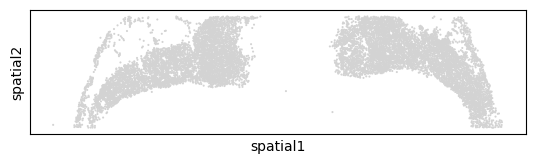

In [8]:
sc.pl.spatial(e11[e11.obs['library_id'] == 'e11_1'], spot_size = 80)

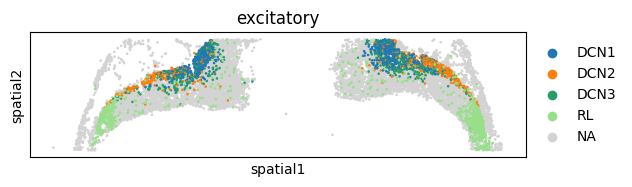

In [9]:
sc.pl.spatial(e11[e11.obs['library_id'] == 'e11_1'], color = "excitatory", spot_size = 100)

Unique excitatory categories:
['DCN1', 'DCN2', NaN, 'RL']
Categories (3, object): ['DCN1', 'DCN2', 'RL']


/tmp/ipykernel_3603089/4197791198.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  e11_slice.obs["excitatory_str"] = e11_slice.obs["excitatory"].astype(str)
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing 

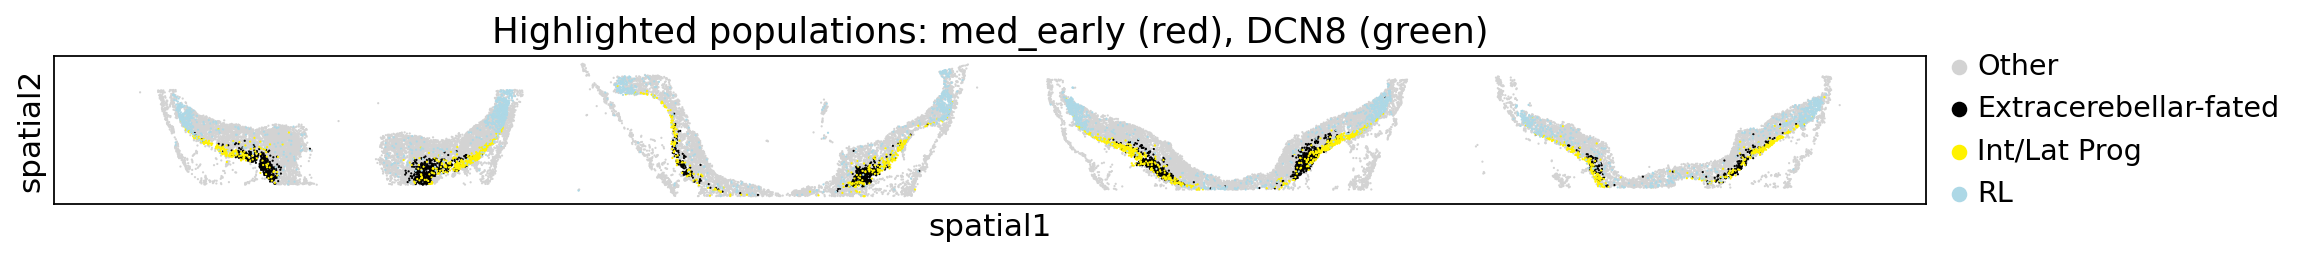

In [17]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

# highlight targets
highlight = ["DCN1", "DCN2", "DCN3", "RL"]
import numpy as np

e11_slice = e11.copy()

coords = e11_slice.obsm["spatial"].copy()

library_ids = e11_slice.obs["library_id"].unique()

for i, lib in enumerate(library_ids):
    mask = (e11_slice.obs["library_id"] == lib).values

    # Center this library around (0, 0)
    lib_coords = coords[mask].copy()
    lib_coords[:, 0] -= lib_coords[:, 0].mean()
    lib_coords[:, 1] -= lib_coords[:, 1].mean()

    # Shift each library along x
    lib_coords[:, 0] += i * 20000

    coords[mask] = lib_coords

e11_slice.obsm["spatial"] = coords
#e11_slice = e11#[e11.obs['library_id'] == 'e11_1']
e11_slice = e11_slice[e11_slice.obs['excitatory'] != 'DCN3']

# --- verify category names ---
print("Unique excitatory categories:")
print(e11_slice.obs["excitatory"].unique())

# if the column is categorical, cast to string for safe comparison
e11_slice.obs["excitatory_str"] = e11_slice.obs["excitatory"].astype(str)

# mark highlighted vs other
e11_slice.obs["excitatory_group"] = np.where(
    e11_slice.obs["excitatory_str"].isin(highlight),
    e11_slice.obs["excitatory_str"],
    "Other"
)

remap = {
    "DCN1": "Extracerebellar-fated",
    "DCN2": "Int/Lat Prog",
    #"DCN5": "DCN2",
    #"DCN3": "RL",
    "RL": "RL",
}
e11_slice.obs["excitatory_group"] = (
    e11_slice.obs["excitatory_str"].map(remap).fillna("Other")
).astype("category")

# Optional: control category order to keep legend stable
order = ["Extracerebellar-fated", "Int/Lat Prog", "RL", "Other"]
cats_present = [c for c in order if c in e11_slice.obs["excitatory_group"].cat.categories]
e11_slice.obs["excitatory_group"] = e11_slice.obs["excitatory_group"].cat.set_categories(cats_present, ordered=True)

# 2) ASSIGN COLORS for the *remapped* categories
palette = {
    "Other" : "lightgrey",
    "Extracerebellar-fated" : 'black',#"Midbrain-fated",
    "Int/Lat Prog" : 'yellow',#"#earlyInt/Lat",
    "DCN3" : 'yellow',#"#earlyInt/Lat",
    "RL" : 'lightblue'#"RL"
    #"DCN8": "#00a86b"        # green
}

e11_slice.obs["excitatory_group"] = e11_slice.obs["excitatory_group"].astype("category")

# colors
palette = {
    "Other" : "lightgrey",
    "Extracerebellar-fated" : 'black',#"Midbrain-fated",
    "Int/Lat Prog" : '#FFF200',#"#earlyInt/Lat",
    #"DCN3" : 'black',#"Midbrain-fated", 
    "RL" : 'lightblue'#"RL"
    #"DCN8": "#00a86b"        # green
}

# --- two-layer plot ---
sc.set_figure_params(figsize=(15, 15))
fig, ax = plt.subplots(figsize=(15, 15))

# background (grey)
sc.pl.spatial(
    e11_slice[e11_slice.obs["excitatory_group"] == "Other"],
    color="excitatory_group",
    palette=palette,
    spot_size=100,
    ax=ax,
    show=False
)

# overlay highlights
for pop in ["Extracerebellar-fated", "Int/Lat Prog", "RL"]:
    sc.pl.spatial(
        e11_slice[e11_slice.obs["excitatory_group"] == pop],
        color="excitatory_group",
        palette=palette,
        spot_size=100,
        ax=ax,
        show=False
    )




In [18]:
e11_slice.obsm['spatial'][:,1] = np.max(e11_slice.obsm['spatial'][:,1]) - e11_slice.obsm['spatial'][:,1]

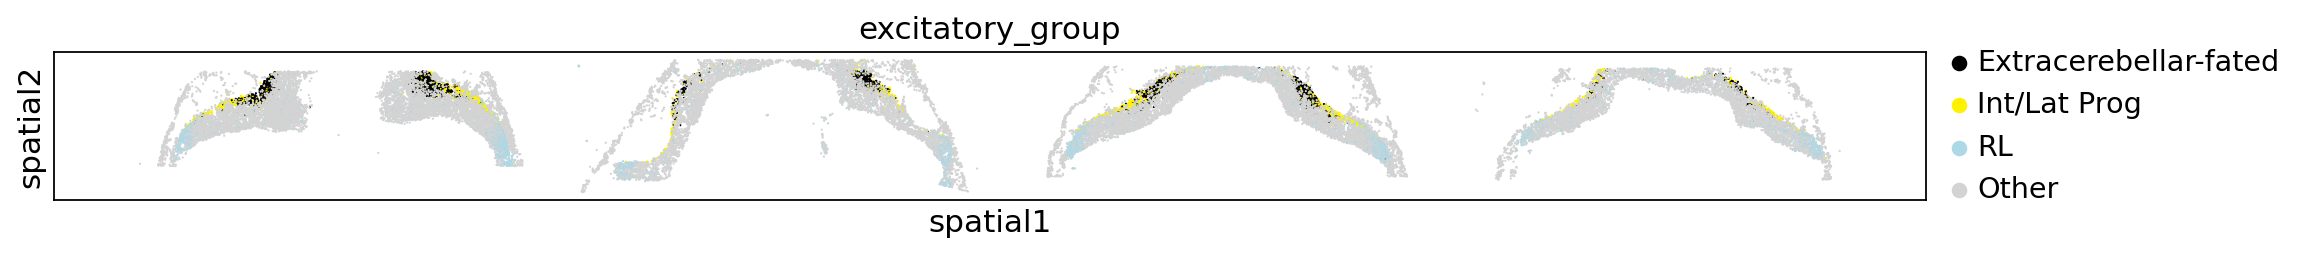

In [23]:
sc.pl.spatial(
        e11_slice,
        color="excitatory_group",
        palette=palette,
        spot_size=100,
        
        show=True
)

In [24]:
e11_slice.write_h5ad('website_data/e11.h5ad')

In [25]:
e12 = sc.read_h5ad("../individual_tp_cell_types/adata_objects/e12_celltypes_spatialclustering.h5ad")

In [26]:
e12

AnnData object with n_obs × n_vars = 26318 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'leiden', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'
    layers: 'counts', 'lognorm', 'normalized', 'regressed', 'scaled'

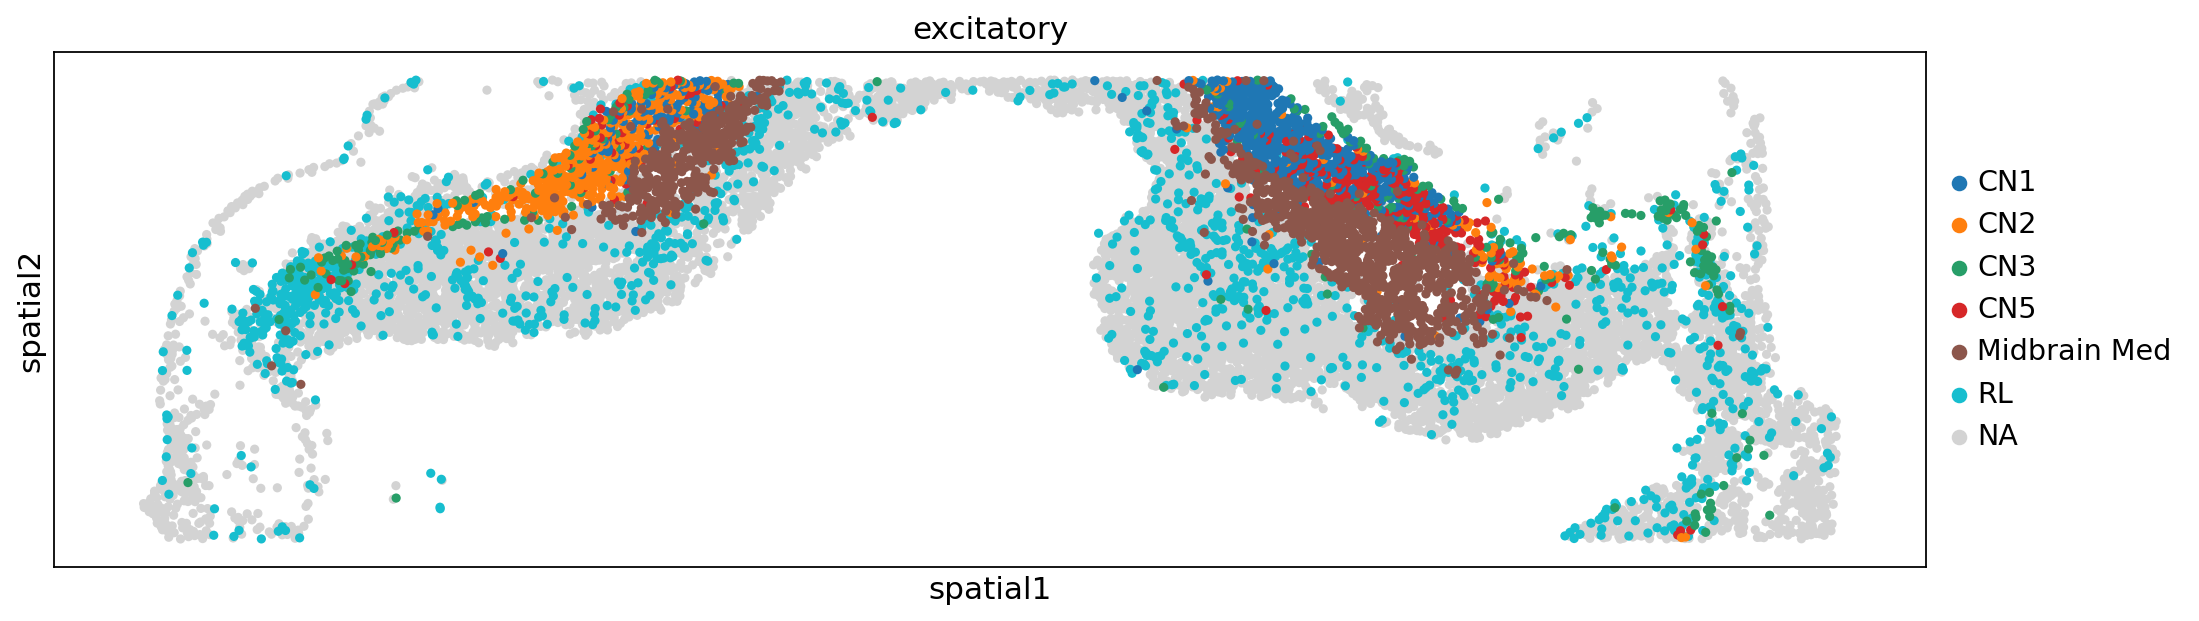

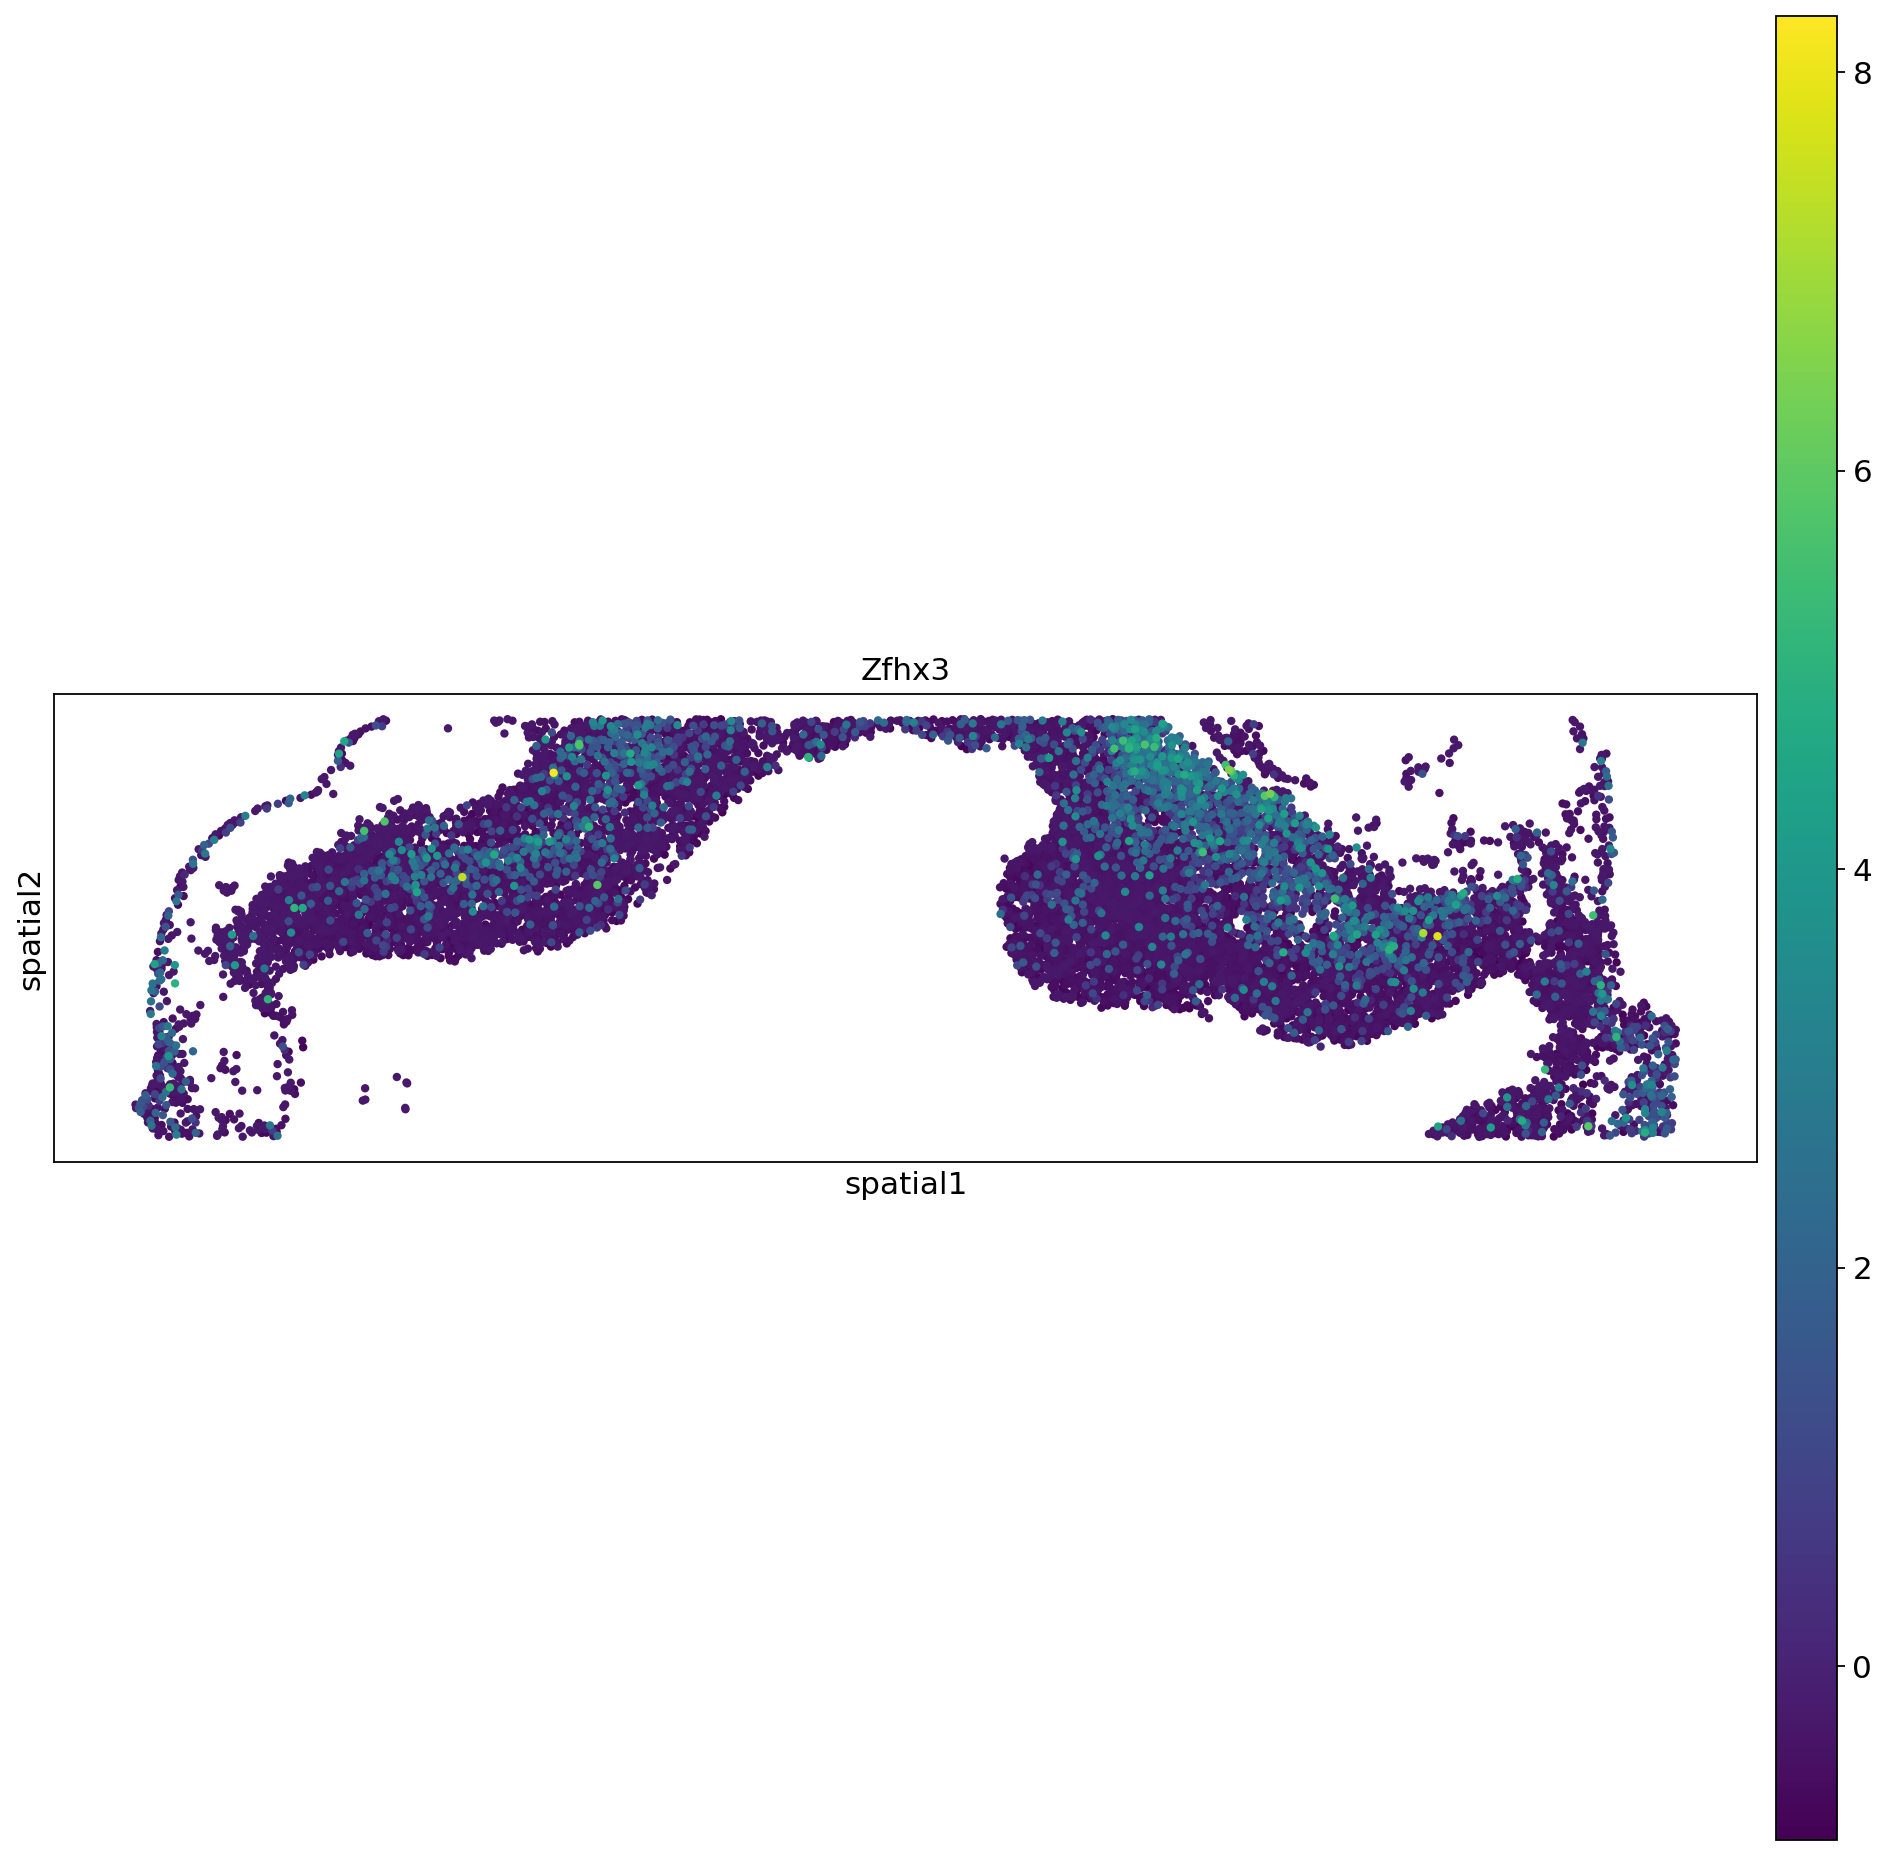

In [27]:
sc.pl.spatial(e12[e12.obs['library_id'] == 'e12_1'], color = "excitatory", spot_size = 100)
sc.pl.spatial(e12[e12.obs['library_id'] == 'e12_1'], color = "Zfhx3", spot_size = 100)

[<Axes: title={'center': 'excitatory_group'}, xlabel='spatial1', ylabel='spatial2'>]

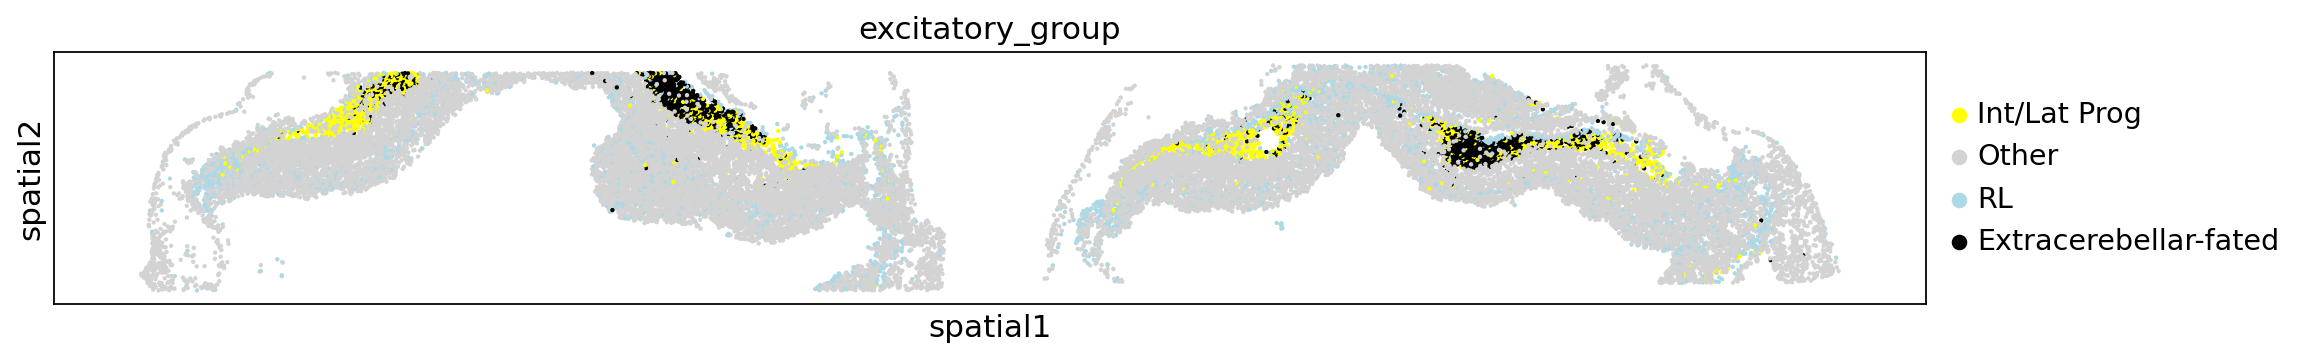

In [29]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# slice (keep your variable name if you like)
#e12_slice = e12[e12.obs['library_id'] == 'e12_1'].copy()
e12_slice = e12.copy()

coords = e12_slice.obsm["spatial"].copy()

library_ids = e12_slice.obs["library_id"].unique()

for i, lib in enumerate(library_ids):
    mask = (e12_slice.obs["library_id"] == lib).values

    # Center this library around (0, 0)
    lib_coords = coords[mask].copy()
    lib_coords[:, 0] -= lib_coords[:, 0].mean()
    lib_coords[:, 1] -= lib_coords[:, 1].mean()

    # Shift each library along x
    lib_coords[:, 0] += i * 20000

    coords[mask] = lib_coords

e12_slice.obsm["spatial"] = coords
# ensure string labels
e12_slice.obs["excitatory_str"] = e12_slice.obs["excitatory"].astype(str)

# 1) REMAP to grouped/renamed categories
# - fix "Mibrain" -> "Midbrain"
# - group CN1, CN21, CN7 into "CN" (edit as needed)
remap = {
    "CN1": "Extracerebellar-fated",
    "CN2": "Int/Lat Prog",
    "CN5": "Int/Lat Prog",
    "CN3": "RL",
    "RL": "RL",
}
e12_slice.obs["excitatory_group"] = (
    e12_slice.obs["excitatory_str"].map(remap).fillna("Other")
).astype("category")

# Optional: control category order to keep legend stable
order = ["Int/Lat Prog", "Other", "RL", "Extracerebellar-fated"]
cats_present = [c for c in order if c in e12_slice.obs["excitatory_group"].cat.categories]
e12_slice.obs["excitatory_group"] = e12_slice.obs["excitatory_group"].cat.set_categories(cats_present, ordered=True)

# 2) ASSIGN COLORS for the *remapped* categories
palette = {
    "Other" : "lightgrey",
    "Extracerebellar-fated" : 'black',#"Midbrain-fated",
    "Int/Lat Prog" : 'yellow',#"#earlyInt/Lat",
    "Int/Lat Prog" : 'yellow',#"#earlyInt/Lat",
    "RL" : 'lightblue'#"RL"
    #"DCN8": "#00a86b"        # green
}

# 3) PLOT (two-layer: background 'Other' then overlays)
sc.set_figure_params(figsize=(15, 15))
fig, ax = plt.subplots(figsize=(15, 15))

# background
sc.pl.spatial(
    e12_slice,
    color="excitatory_group",
    palette=palette,
    spot_size=100,
    ax=ax,
    show=False
)




In [30]:
e12_slice.write_h5ad('website_data/e12.h5ad')

In [31]:
e13 = sc.read_h5ad("../individual_tp_cell_types/adata_objects/e13_celltypes_spatialclustering.h5ad")
e13.obs['excitatory']

14       dcn5
22       dcn2
29       dcn2
36       dcn2
105      dcn2
         ... 
38732     NaN
38735     NaN
38741     NaN
38744     NaN
38760     NaN
Name: excitatory, Length: 31066, dtype: category
Categories (11, object): ['Midbrain-fated', 'Outside_Cb', 'Prog1', 'Prog2', ..., 'dcn3', 'dcn4', 'dcn5', 'other']

[<Axes: title={'center': 'excitatory_group'}, xlabel='spatial1', ylabel='spatial2'>]

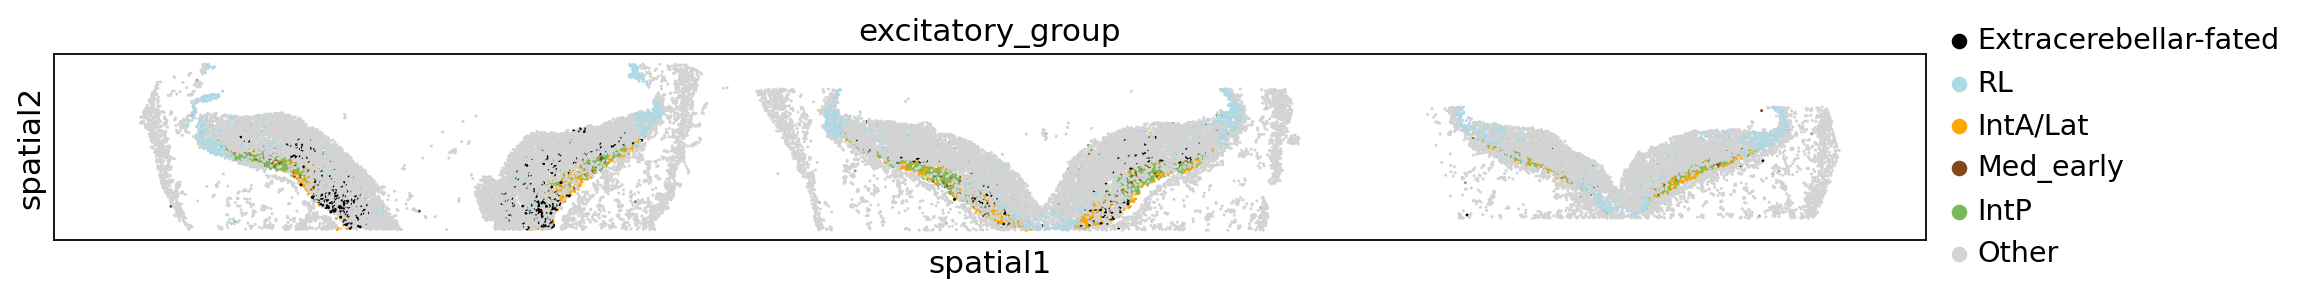

In [36]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# slice (keep your variable name if you like)
#e13_slice = e13[e13.obs['library_id'] == 'e13_1'].copy()

# ensure string labels


e13_slice = e13.copy()
e13_slice.obs["excitatory_str"] = e13_slice.obs["excitatory"].astype(str)

coords = e13_slice.obsm["spatial"].copy()

library_ids = e13_slice.obs["library_id"].unique()

for i, lib in enumerate(library_ids):
    mask = (e13_slice.obs["library_id"] == lib).values

    # Center this library around (0, 0)
    lib_coords = coords[mask].copy()
    lib_coords[:, 0] -= lib_coords[:, 0].mean()
    lib_coords[:, 1] -= lib_coords[:, 1].mean()

    # Shift each library along x
    lib_coords[:, 0] += i * 20000

    coords[mask] = lib_coords

e13_slice.obsm["spatial"] = coords

# 1) REMAP to grouped/renamed categories
# - fix "Mibrain" -> "Midbrain"
# - group CN1, CN21, CN7 into "CN" (edit as needed)
remap = {
    "Other" : "lightgrey",
    "Midbrain-fated" : 'Extracerebellar-fated',#"Midbrain-fated",
    "dcn2":"IntP",
    #"dcn5":"DCN4",
    "dcn1" : 'IntA/Lat',
    "dcn4" : 'IntA/Lat',
    "dcn5":"Med_early",
    "dcn3" : 'IntP',#"Midbrain-fated", 
    "RL" : 'RL',#"RL"
    #"dcn5" : 'DCN3'#"RL"
    #"DCN8": "#00a86b"        # green
}
e13_slice.obs["excitatory_group"] = (
    e13_slice.obs["excitatory_str"].map(remap).fillna("Other")
).astype("category")

# Optional: control category order to keep legend stable
order = ["Extracerebellar-fated", "Int/Lat","RL", "IntA/Lat",  "Med_early","IntP",  "Other"]
cats_present = [c for c in order if c in e13_slice.obs["excitatory_group"].cat.categories]
e13_slice.obs["excitatory_group"] = e13_slice.obs["excitatory_group"].cat.set_categories(cats_present, ordered=True)

# 2) ASSIGN COLORS for the *remapped* categories
palette = {
    "Other" : "lightgrey",
    "Extracerebellar-fated" : 'black',#"Midbrain-fated",
    "Int/Lat" : 'yellow',#"#earlyInt/Lat",
    "Med_early" : '#824819',#"Midbrain-fated", 
    "RL" : 'lightblue',#"RL"
    #"DCN8": "#00a86b"        # green
    "IntP": "#78B958",
    "IntA/Lat": "#FCA800"
}

# 3) PLOT (two-layer: background 'Other' then overlays)
sc.set_figure_params(figsize=(15, 15))
fig, ax = plt.subplots(figsize=(15, 15))

# background
sc.pl.spatial(
    e13_slice,
    color="excitatory_group",
    palette=palette,
    spot_size=100,
    ax=ax,
    show=False
)

# overlays


In [38]:
e13_slice.obsm['spatial'][:,1] = np.max(e13_slice.obsm['spatial'][:,1]) - e13_slice.obsm['spatial'][:,1]

In [39]:
e13_slice.write_h5ad('website_data/e13.h5ad')

In [40]:
e13_5 = sc.read_h5ad("../individual_tp_cell_types/adata_objects/e13_5_celltypes_spatialclustering.h5ad")



In [41]:
e13_5

AnnData object with n_obs × n_vars = 50746 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'hybrid_leiden', 'cell_types', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'lognorm', 'normalized', 'regressed', 'scaled'

[<Axes: title={'center': 'excitatory_group'}, xlabel='spatial1', ylabel='spatial2'>]

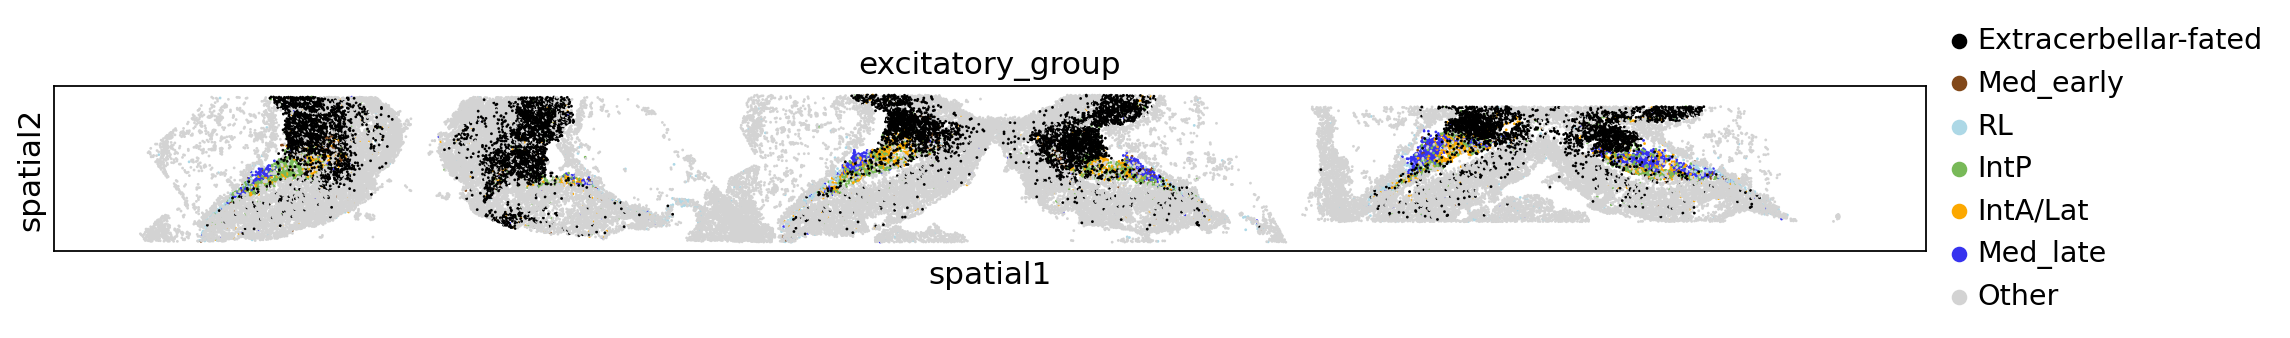

In [42]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# slice (keep your variable name if you like)
#e13_5_slice = e13_5[e13_5.obs['library_id'] == 'e13_11'].copy()

# ensure string labels
#e13_5_slice.obs["excitatory_str"] = e13_5_slice.obs["excitatory"].astype(str)

e13_5_slice = e13_5.copy()
e13_5_slice.obs["excitatory_str"] = e13_5_slice.obs["excitatory"].astype(str)

coords = e13_5_slice.obsm["spatial"].copy()

library_ids = e13_5_slice.obs["library_id"].unique()

for i, lib in enumerate(library_ids):
    mask = (e13_5_slice.obs["library_id"] == lib).values

    # Center this library around (0, 0)
    lib_coords = coords[mask].copy()
    lib_coords[:, 0] -= lib_coords[:, 0].mean()
    lib_coords[:, 1] -= lib_coords[:, 1].mean()

    # Shift each library along x
    lib_coords[:, 0] += i * 20000

    coords[mask] = lib_coords

e13_5_slice.obsm["spatial"] = coords


# 1) REMAP to grouped/renamed categories
# - fix "Mibrain" -> "Midbrain"
# - group CN1, CN21, CN7 into "CN" (edit as needed)
remap = {
    "Other" : "Other",
    #"DCN9" : 'DCN3',
    "med_early" : "Med_early",
    "int/lat_prog" : 'IntP',
    "intp":"IntP",
    "lat" : 'IntA/Lat',
    "Midbrain":"Extracerbellar-fated",
    "med1": "Med_late",#MedialDCN
    "med2":"Med_late",
    "Medial": "Med_late", #MedialDCN
    "RL":"RL"
}


e13_5_slice.obs["excitatory_group"] = (
    e13_5_slice.obs["excitatory_str"].map(remap).fillna("Other")
).astype("category")
e13_5.obs["excitatory_str"] = e13_5.obs["excitatory"].astype(str)

e13_5.obs["excitatory_group"] = (
    e13_5.obs["excitatory_str"].map(remap).fillna("Other")
).astype("category")

# Optional: control category order to keep legend stable
order = ["Extracerbellar-fated", "Med_early", "RL", "IntP", "IntA/Lat", "Med_late", "Other"]
cats_present = [c for c in order if c in e13_5_slice.obs["excitatory_group"].cat.categories]
e13_5_slice.obs["excitatory_group"] = e13_5_slice.obs["excitatory_group"].cat.set_categories(cats_present, ordered=True)

# 2) ASSIGN COLORS for the *remapped* categories
palette = {
    "Other" : "lightgrey",
    "Extracerbellar-fated" : 'black',#"Midbrain-fated",
    #"DCN2" : 'yellow',#"#earlyInt/Lat",
    "Med_early" : '#824819',#"Midbrain-fated", 
    "RL" : 'lightblue',#"RL"
    #"DCN8": "#00a86b"        # green
    "IntP": "#78B958",
    "IntA/Lat": "#FCA800",
    "Med_late": "#3733EF"
}

# 3) PLOT (two-layer: background 'Other' then overlays)
sc.set_figure_params(figsize=(15, 15))
fig, ax = plt.subplots(figsize=(15, 15))

# background
sc.pl.spatial(
    e13_5_slice,
    color="excitatory_group",
    palette=palette,
    spot_size=100,
    ax=ax,
    show=False)

In [43]:
e13_5_slice.write_h5ad('website_data/e13_5.h5ad')

In [10]:
e14 = sc.read_h5ad("../individual_tp_cell_types/adata_objects/e14_celltypes_spatialclustering.h5ad")
e14.obsm['spatial'][:,1] = np.max(e14.obsm['spatial'][:,1]) - e14.obsm['spatial'][:,1]

e14

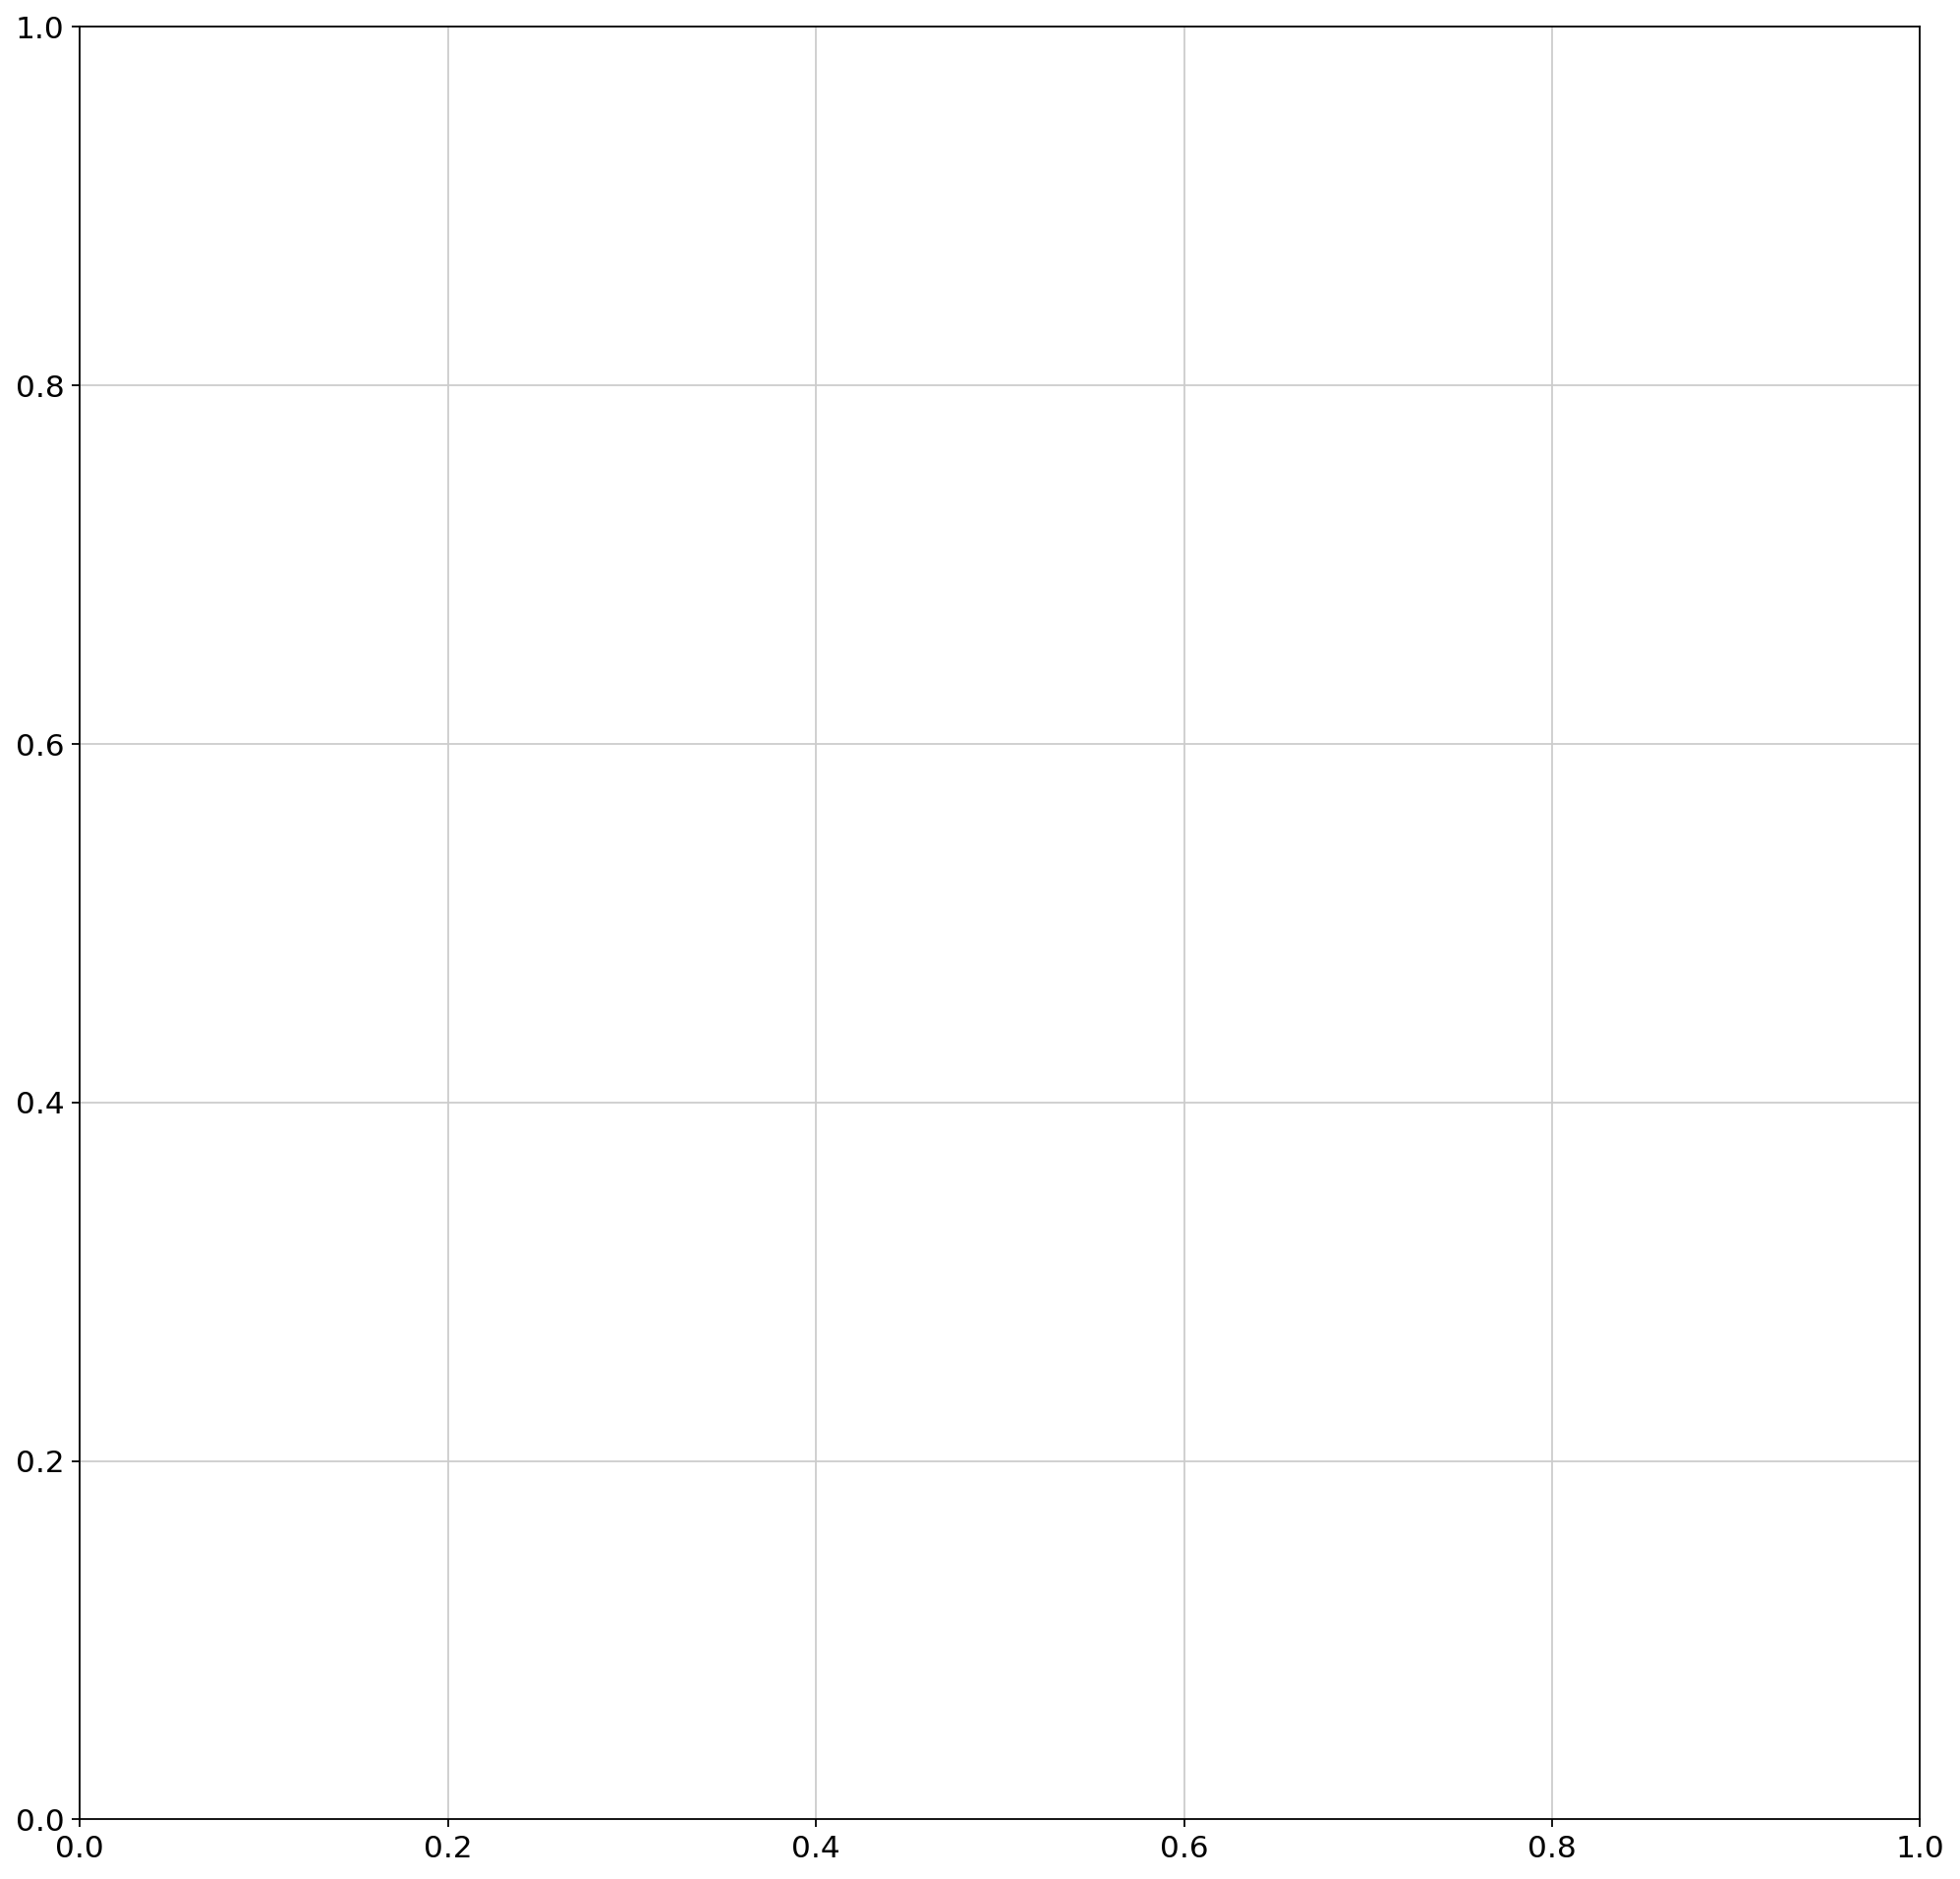

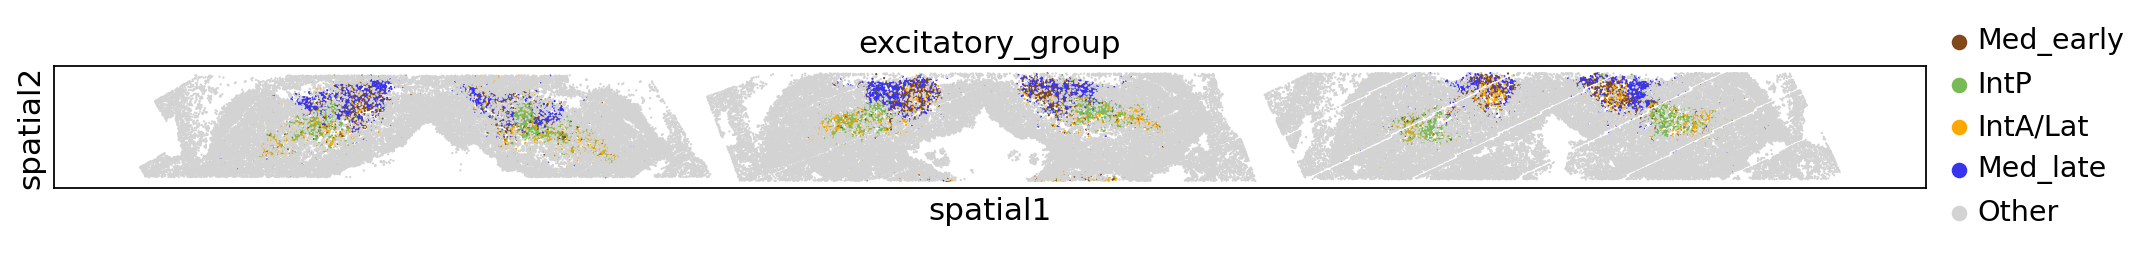

In [15]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# slice (keep your variable name if you like)
#e14_slice = e14[e14.obs['library_id'] == 'e14_2'].copy()



e14_slice = e14.copy()
e14_slice.obs["excitatory_str"] = e14_slice.obs["excitatory"].astype(str)

coords = e14_slice.obsm["spatial"].copy()

library_ids = e14_slice.obs["library_id"].unique()

for i, lib in enumerate(library_ids):
    mask = (e14_slice.obs["library_id"] == lib).values

    # Center this library around (0, 0)
    lib_coords = coords[mask].copy()
    lib_coords[:, 0] -= lib_coords[:, 0].mean()
    lib_coords[:, 1] -= lib_coords[:, 1].mean()

    # Shift each library along x
    lib_coords[:, 0] += i * 25000

    coords[mask] = lib_coords

e14_slice.obsm["spatial"] = coords

# ensure string labels
e14_slice.obs["excitatory_str"] = e14_slice.obs["excitatory"].astype(str)

# 1) REMAP to grouped/renamed categories
# - fix "Mibrain" -> "Midbrain"
# - group CN1, CN21, CN7 into "CN" (edit as needed)
remap = {
    "Other" : "Other",
    "IntP" : 'IntP',#"Midbrain-fated",
    "IntA/Lat" : 'IntA/Lat',
    "Med1": "Med_late",#MedialDCN
    "Med2": "Med_early", #MedialDCN
    #"X" : 'DCN5'
}


e14_slice.obs["excitatory_group"] = (
    e14_slice.obs["excitatory_str"].map(remap).fillna("Other")
).astype("category")

# Optional: control category order to keep legend stable
order = [  "Med_early", "RL", "IntP", "IntA/Lat", "Med_late", "Other"]
cats_present = [c for c in order if c in e14_slice.obs["excitatory_group"].cat.categories]
e14_slice.obs["excitatory_group"] = e14_slice.obs["excitatory_group"].cat.set_categories(cats_present, ordered=True)

# 2) ASSIGN COLORS for the *remapped* categories
palette = {
    "Other" : "lightgrey",
    #"DCN1" : 'black',#"Midbrain-fated",
    #"DCN2" : 'orange',#"#earlyInt/Lat",
    "Med_early" : '#824819',#"Midbrain-fated", 
    "RL" : 'lightblue',#"RL"
    #"DCN8": "#00a86b"        # green
    "IntP": "#78B958",
    "IntA/Lat": "#FCA800",
    "Med_late": "#3733EF"
}

# 3) PLOT (two-layer: background 'Other' then overlays)
sc.set_figure_params(figsize=(15, 15))
fig, ax = plt.subplots(figsize=(15, 15))

# background
sc.pl.spatial(
    e14_slice,
    color="excitatory_group",
    palette=palette,
    spot_size=100
)




In [18]:
e14_slice.write_h5ad('website_data/e14.h5ad')

In [19]:
e15 = sc.read_h5ad("../individual_tp_cell_types/e15_cell_types_5-27-2025spatial_8-11.h5ad")
e15

AnnData object with n_obs × n_vars = 153433 × 1752
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'cell_type', 'finer_cell_types', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'excitatory_colors', 'finer_cell_types_colors', 'inhibitory_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

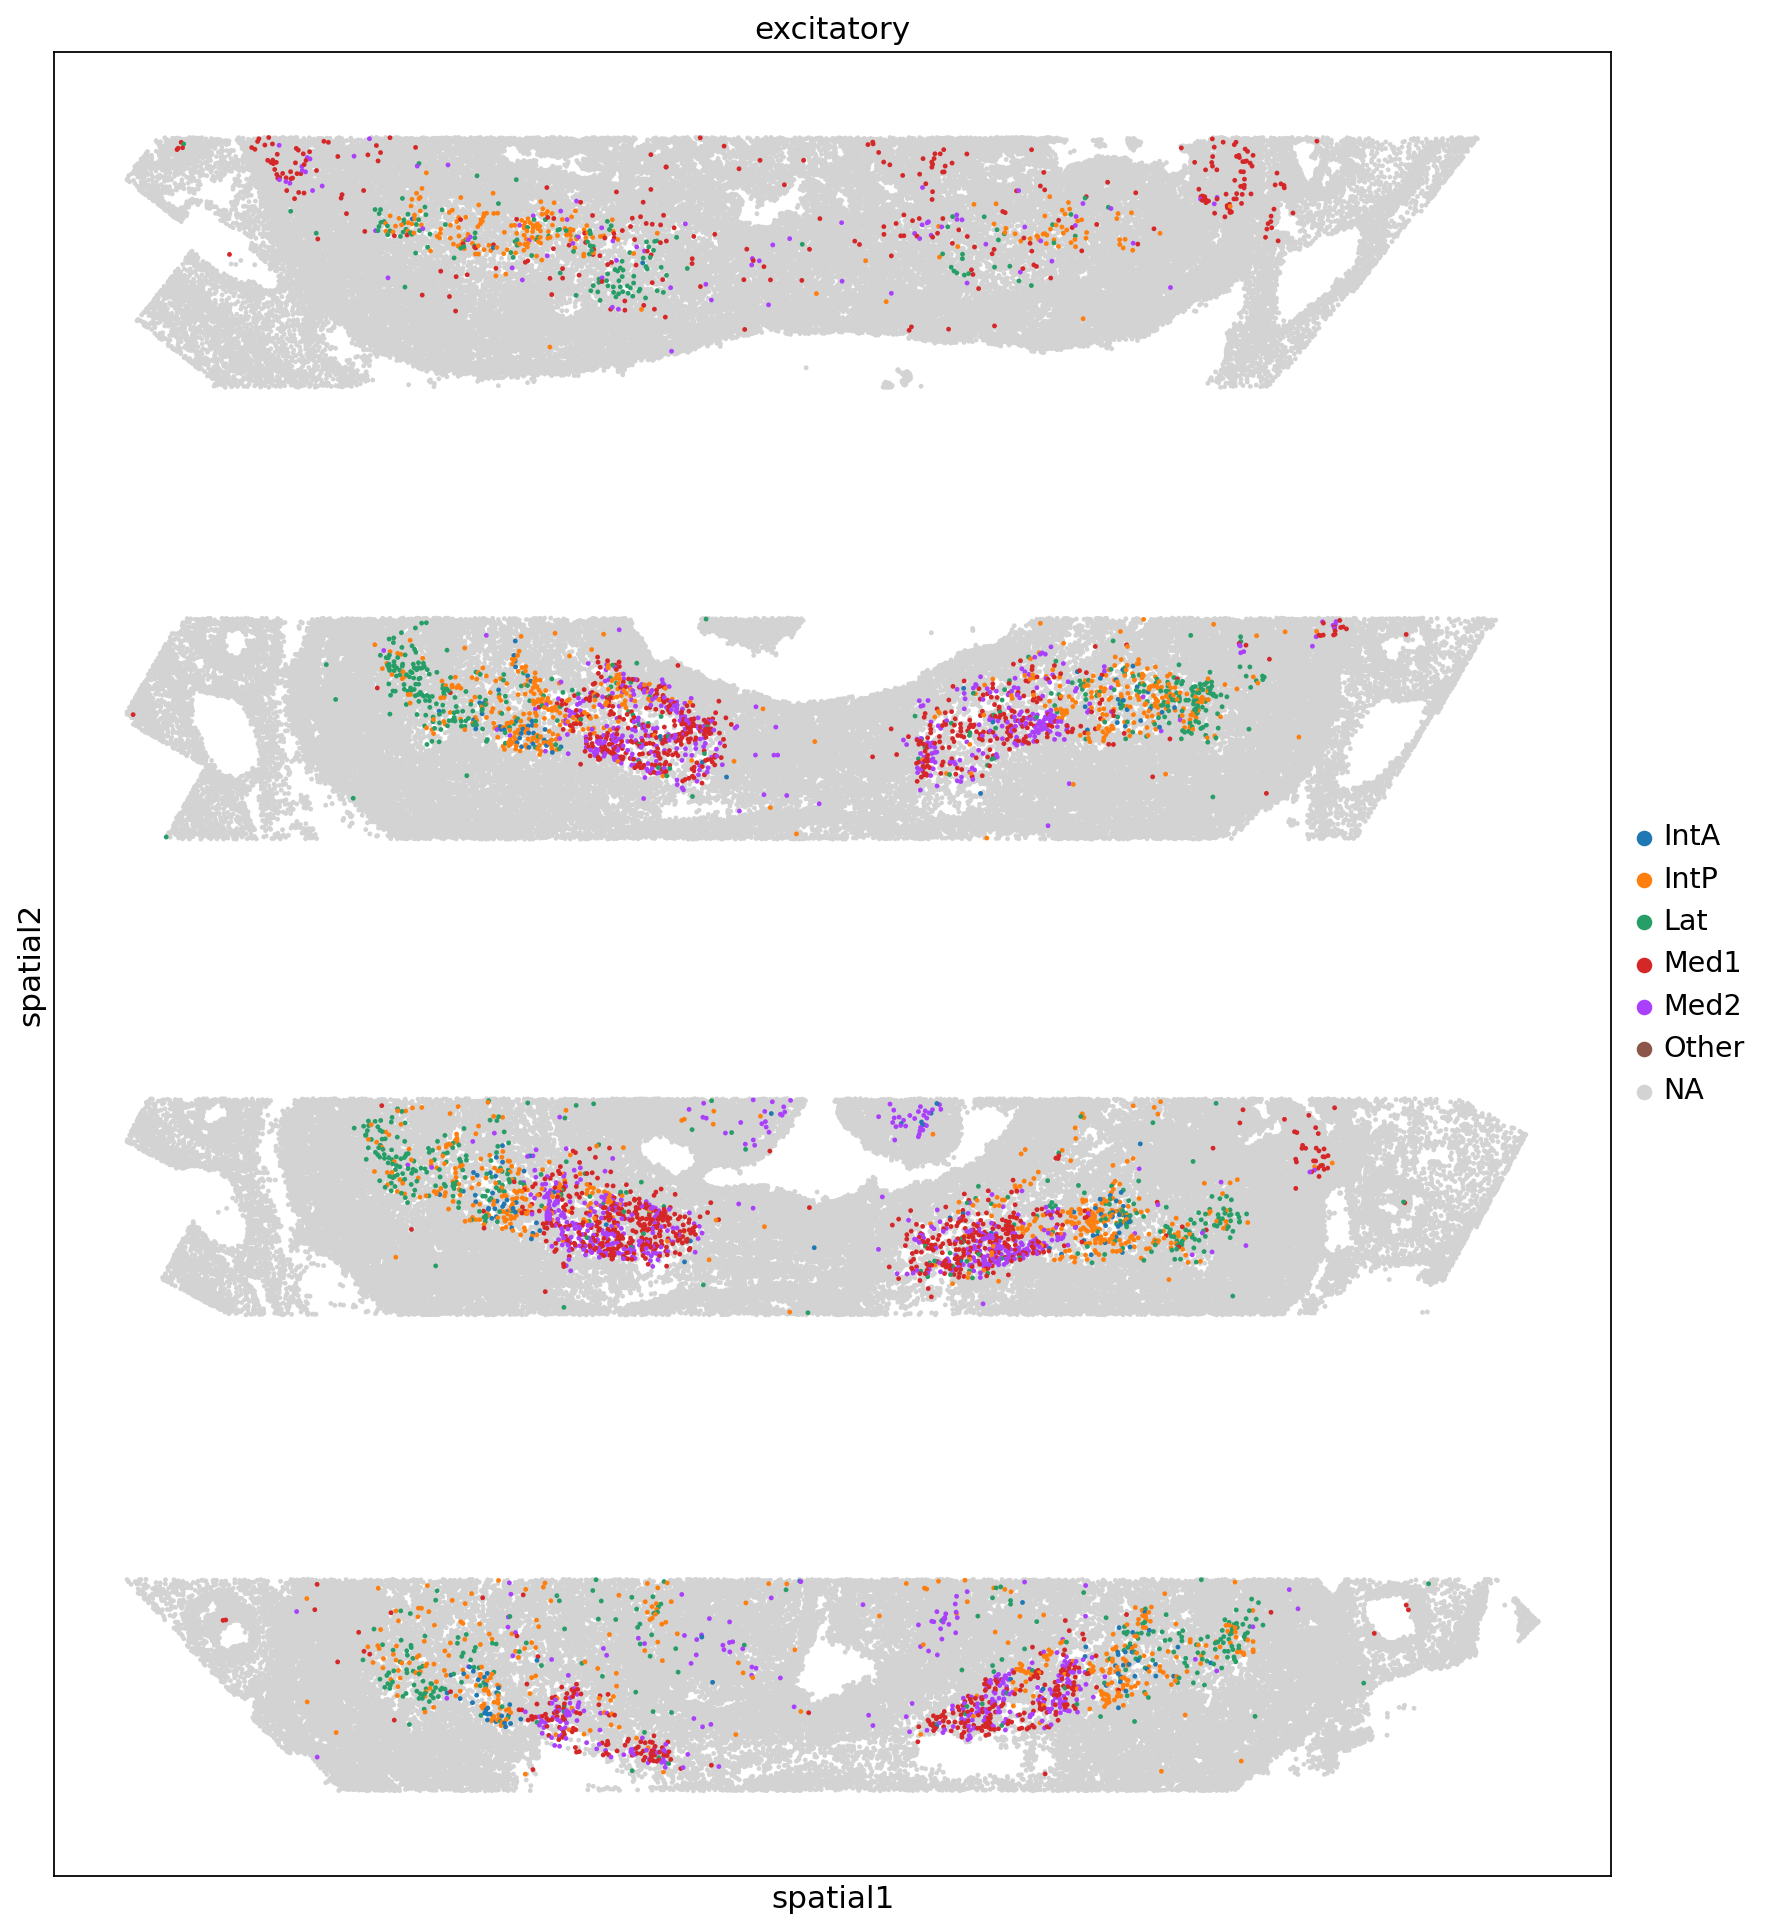

In [20]:
sc.set_figure_params(figsize = (15,15))
sc.pl.spatial(e15, color = "excitatory", spot_size = 100)

In [32]:
e15_slice.obs["excitatory"]

50        Med1
131       IntP
328       IntP
533       IntP
539        Lat
          ... 
155121     NaN
155122     NaN
155123     NaN
155124     NaN
155130     NaN
Name: excitatory, Length: 153433, dtype: category
Categories (6, object): ['IntA', 'IntP', 'Lat', 'Med1', 'Med2', 'Other']

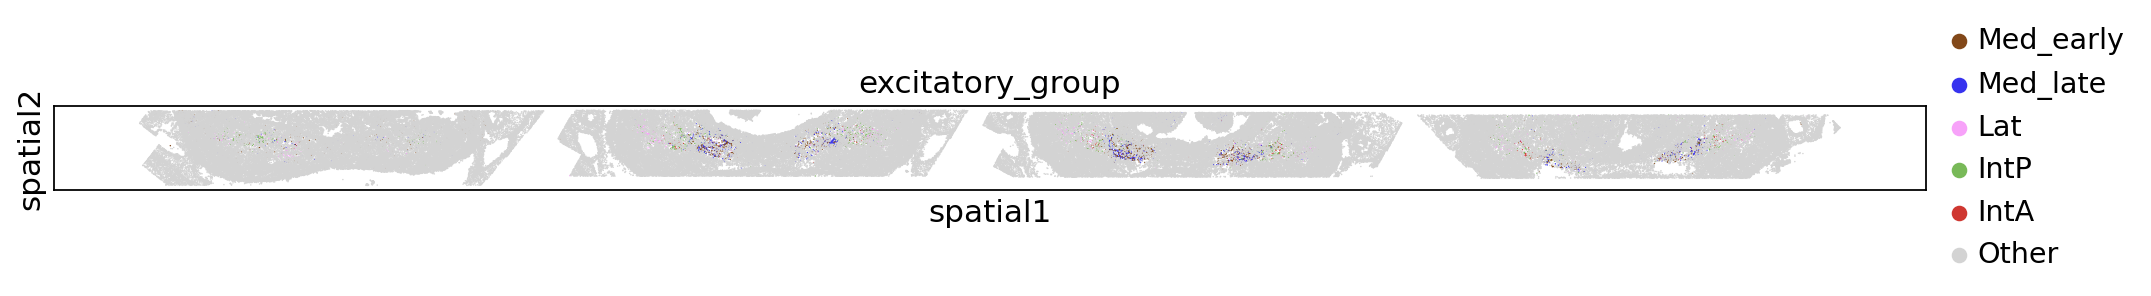

In [34]:

e15_slice = e15.copy()
e15_slice.obs["excitatory_str"] = e15_slice.obs["excitatory"].astype(str)

coords = e15_slice.obsm["spatial"].copy()

library_ids = e15_slice.obs["library_id"].unique()

for i, lib in enumerate(library_ids):
    mask = (e15_slice.obs["library_id"] == lib).values

    # Center this library around (0, 0)
    lib_coords = coords[mask].copy()
    lib_coords[:, 0] -= lib_coords[:, 0].mean()
    lib_coords[:, 1] -= lib_coords[:, 1].mean()

    # Shift each library along x
    lib_coords[:, 0] += i * 30000

    coords[mask] = lib_coords

e15_slice.obsm["spatial"] = coords

e15_slice.obs["excitatory_str"] = e15_slice.obs["excitatory"].astype(str)


# 2) Map using a dict on the *normalized* keys
remap = {
    "IntA": "IntA",
    "IntP": "IntP",
    "Lat":  "Lat",
    "Med1": "Med_early",
    "Med2": "Med_late",
    "other":"Other",
    "sps3": "SPS2",
}


# 3) Inspect what's not mapping (for debugging)


# 4) Stable order/colors

e15_slice.obs["excitatory_group"] = (
    e15_slice.obs["excitatory_str"].map(remap).fillna("Other")
).astype("category")

# Optional: control category order to keep legend stable
order = ["Med_early","Med_late","Lat","RL","IntP","IntA","Other"]
cats_present = [c for c in order if c in e15_slice.obs["excitatory_group"].cat.categories]
e15_slice.obs["excitatory_group"] = e15_slice.obs["excitatory_group"].cat.set_categories(cats_present, ordered=True)

color_map = {
   "Other" : "lightgrey",
    "Med_early" : '#824819',#"Midbrain-fated", 
    "RL" : 'lightblue',#"RL"
    #"DCN8": "#00a86b"        # green
    "IntP": "#78B958",
    "Lat": "#F7A2F9",
    "IntA": "#CF3731",
    "Med_late": "#3733EF"
}

sc.pl.spatial(
    e15_slice,
    color="excitatory_group",
    palette=color_map,
    spot_size=100
)


In [35]:
e15_slice.write_h5ad('website_data/e15.h5ad')

In [36]:
import scanpy as sc
e17 = sc.read_h5ad("../individual_tp_cell_types/e17_cell_types_spatial_8-11.h5ad")
e17

AnnData object with n_obs × n_vars = 87554 × 1748
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'hybrid_leiden', 'finer_cell_types', 'cell_type', 'excitatory', 'inhibitory'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'log1p_mean_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'finer_cell_types_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'generic', 'spatial', 'spatial3d'
    varm: 'PCs'

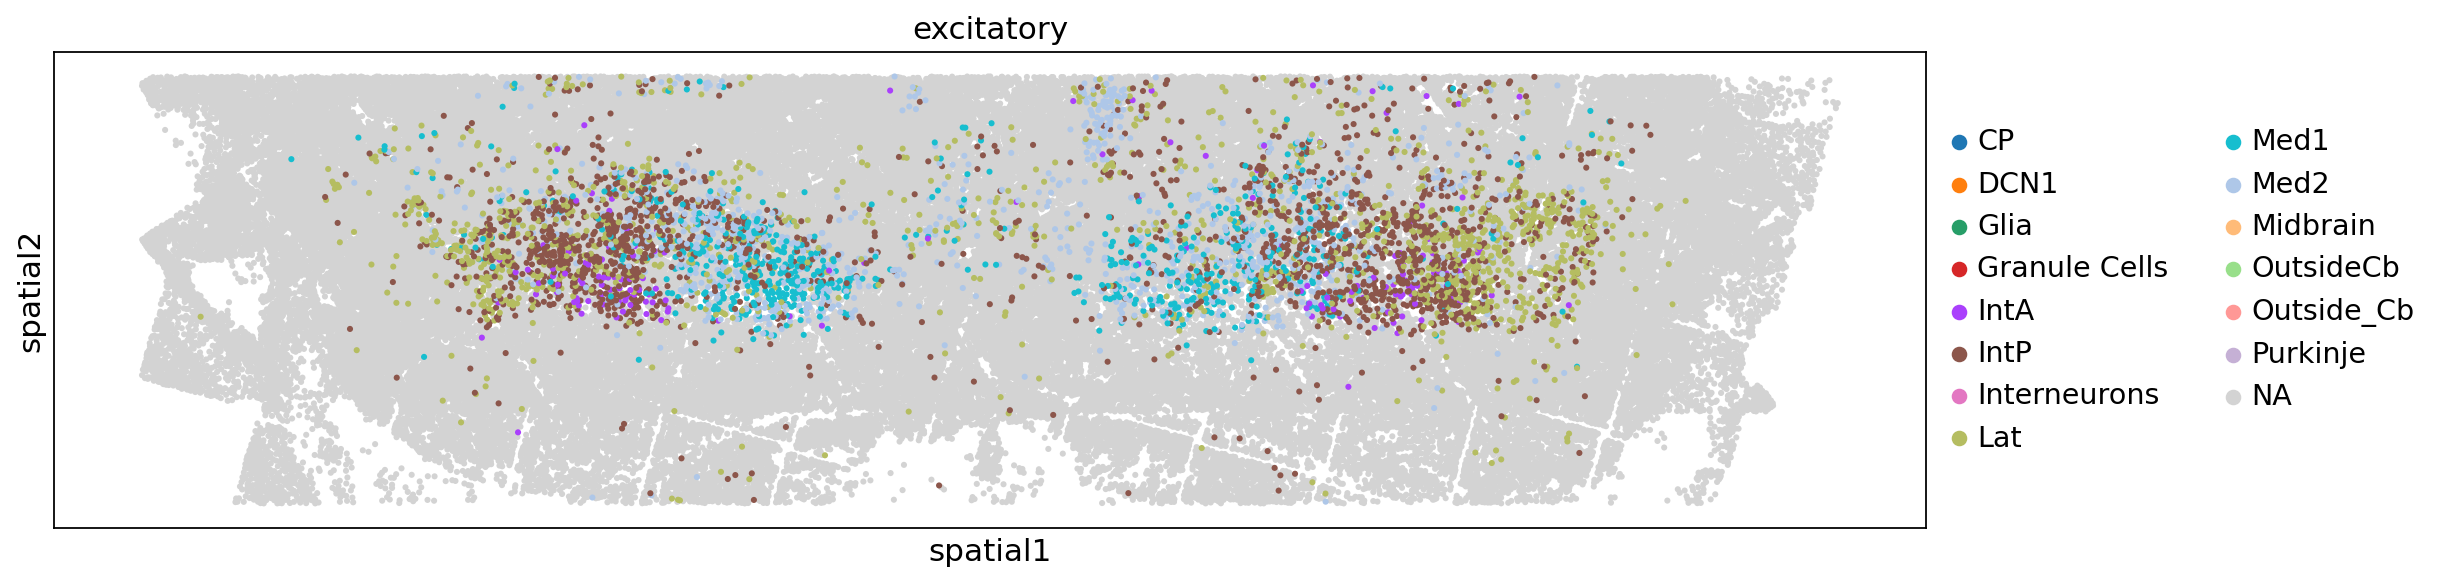

In [41]:
sc.set_figure_params(figsize = (15,15))
sc.pl.spatial(e17, color = "excitatory", spot_size = 100)

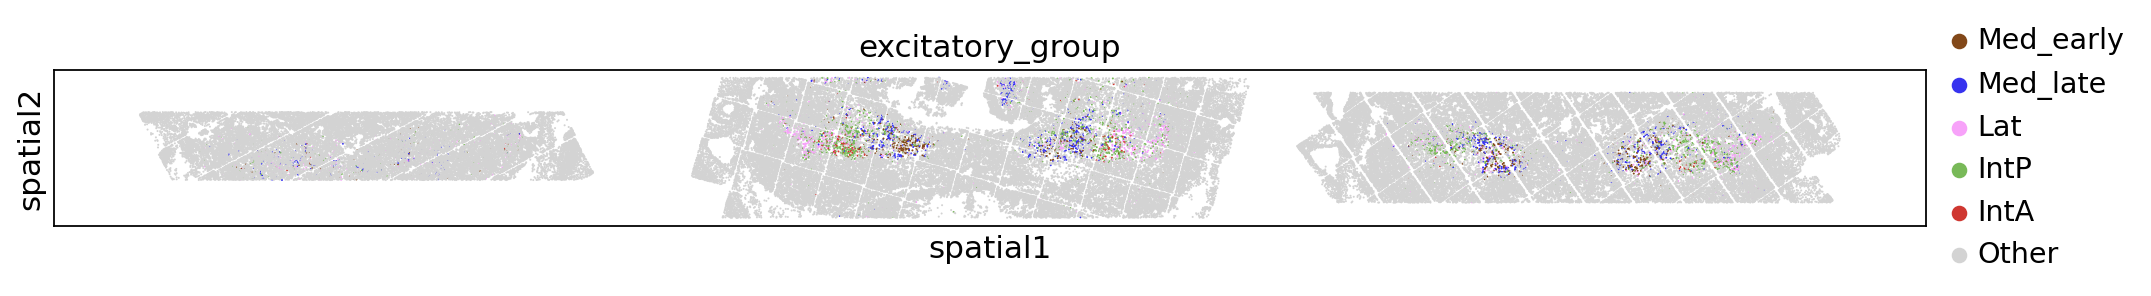

In [42]:

e17_slice = e17.copy()
e17_slice.obs["excitatory_str"] = e17_slice.obs["excitatory"].astype(str)

coords = e17_slice.obsm["spatial"].copy()

library_ids = e17_slice.obs["library_id"].unique()

for i, lib in enumerate(library_ids):
    mask = (e17_slice.obs["library_id"] == lib).values

    # Center this library around (0, 0)
    lib_coords = coords[mask].copy()
    lib_coords[:, 0] -= lib_coords[:, 0].mean()
    lib_coords[:, 1] -= lib_coords[:, 1].mean()

    # Shift each library along x
    lib_coords[:, 0] += i * 30000

    coords[mask] = lib_coords

e17_slice.obsm["spatial"] = coords

e17_slice.obs["excitatory_str"] = e17_slice.obs["excitatory"].astype(str)


# 2) Map using a dict on the *normalized* keys
remap = {
    "IntA": "IntA",
    "IntP": "IntP",
    "Lat":  "Lat",
    "Med1": "Med_early",
    "Med2": "Med_late",
    "other":"Other",
    "sps3": "SPS2",
}


# 3) Inspect what's not mapping (for debugging)


# 4) Stable order/colors

e17_slice.obs["excitatory_group"] = (
    e17_slice.obs["excitatory_str"].map(remap).fillna("Other")
).astype("category")

# Optional: control category order to keep legend stable
order = ["Med_early","Med_late","Lat","RL","IntP","IntA","Other"]
cats_present = [c for c in order if c in e17_slice.obs["excitatory_group"].cat.categories]
e17_slice.obs["excitatory_group"] = e17_slice.obs["excitatory_group"].cat.set_categories(cats_present, ordered=True)

color_map = {
   "Other" : "lightgrey",
    "Med_early" : '#824819',#"Midbrain-fated", 
    "RL" : 'lightblue',#"RL"
    #"DCN8": "#00a86b"        # green
    "IntP": "#78B958",
    "Lat": "#F7A2F9",
    "IntA": "#CF3731",
    "Med_late": "#3733EF"
}

sc.pl.spatial(
    e17_slice,
    color="excitatory_group",
    palette=color_map,
    spot_size=100
)


In [43]:
e17_slice.write_h5ad('website_data/e17.h5ad')